## Cell 1: Read PD files and find raw data files

In [18]:
# Cell 1: Load transition→datetimes from log, then build wait_time_list + raw_file_paths_list
import os
import re
from datetime import datetime
from collections import defaultdict
import io
# -----------------------
# User configuration
# -----------------------
# directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
# Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file

directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file
# log_path = r'bussed_ramsey_detuning_calibration.txt'
log_path = r'Bussed_Ramsey_datetime_log.txt'
directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Bussed_ramsey_detuning_calibration_data\\'

# Choose ONE transition pair for this notebook run (edit these)
target_transitions = [[2, 4, 2], [2, 3, 0]]  # [[m,F,mF],[m,F,mF]]

# -----------------------
# Helpers (Cell 1)
# -----------------------
def parse_filename(filename):
    pattern = (
        r"Ramsey_experiment_\[\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\],\s*"
        r"\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\]\]_(\d+(?:\.\d+)?)_us_(\d+)_"
        r"(\d{8})_(\d{4})"
    )
    match = re.search(pattern, filename)
    if match:
        m1  = int(match.group(1))
        F1  = int(match.group(2))
        mF1 = int(match.group(3))
        m2  = int(match.group(4))
        F2  = int(match.group(5))
        mF2 = int(match.group(6))

        wait_time = float(match.group(7))   # e.g. 16800.1
        comp_flag = int(match.group(8))     # e.g. 0 or 1

        date_str = match.group(9) + match.group(10)  # "YYYYMMDDHHMM"
        date_time = datetime.strptime(date_str, '%Y%m%d%H%M')

        transitions = [(m1, F1, mF1), (m2, F2, mF2)]
        return transitions, wait_time, date_time, comp_flag
    else:
        return None, None, None, None

def extract_raw_data_filenames(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    raw_data_filenames_line = lines[-1].strip()
    raw_data_filenames = [
        name.strip().strip("'\"") for name in raw_data_filenames_line.strip('[]').split(',')
    ]
    return raw_data_filenames

def search_files_by_transitions(directory, target_transitions, target_date_times=None):
    """
    target_transitions: list like [[0, 2, 0], [0, 4, -2]]
    target_date_times: set(datetime) or None
    """
    target_transitions = [tuple(t) for t in target_transitions]

    wait_time_list = []
    raw_file_paths_list = []
    final_transitions = None

    for filename in os.listdir(directory):
        if filename.startswith('Ramsey_experiment'):
            transitions, wait_time, date_time, comp_flag = parse_filename(filename)
            if transitions is None or wait_time is None or date_time is None:
                continue

            # exact match of the two transitions (order matters)
            if transitions == target_transitions:
                if target_date_times and date_time not in target_date_times:
                    continue

                final_transitions = transitions
                file_path = os.path.join(directory, filename)

                raw_data_filenames = extract_raw_data_filenames(file_path)
                raw_data_filepaths = [
                    os.path.join(Z_drive_raw_data, raw_filename)
                    for raw_filename in raw_data_filenames
                ]

                wait_time_list.append(wait_time)
                raw_file_paths_list.append(raw_data_filepaths)

    return wait_time_list, raw_file_paths_list, final_transitions

# def parse_log_file_for_pair(log_path, target_transitions):
#     """
#     Reads your log text file and returns a set(datetime) for a single transition pair.
#     Expects lines like:
#       [[0, 4, -1], [0, 2, 0]], 0, 0, 0, ['20260122_2001', '20260122_2106']
#     """
#     # Normalize target to tuple-of-tuples
#     tkey = (tuple(target_transitions[0]), tuple(target_transitions[1]))

#     # Capture the two [a,b,c] blocks and the final list of quoted datetimes
#     line_re = re.compile(
#         r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
#         r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*,.*?,\s*"
#         r"\[(.*?)\]\s*$"
#     )

#     dt_set = set()

#     with open(log_path, "r") as f:
#         for line in f:
#             line = line.strip()
#             if not line or line.startswith("#"):
#                 continue
#             m = line_re.match(line)
#             if not m:
#                 continue

#             p1 = (int(m.group(1)), int(m.group(2)), int(m.group(3)))
#             p2 = (int(m.group(4)), int(m.group(5)), int(m.group(6)))
#             key = (p1, p2)
#             if key != tkey:
#                 continue

#             dates_blob = m.group(7).strip()
#             date_tokens = re.findall(r"['\"](\d{8}_\d{4})['\"]", dates_blob)
#             for tok in date_tokens:
#                 dt_set.add(datetime.strptime(tok.replace("_", ""), "%Y%m%d%H%M"))

#     return dt_set

import re
from datetime import datetime

def parse_log_file_for_pair(log_path, target_transitions, LT_comp: bool):
    """
    Reads your log text file and returns:
      - dt_set: set(datetime) chosen from Comp False or Comp True list based on LT_comp
      - mean_dev: float mean deviation for that transition pair (or None if not found)

    Expected line formats (tolerant):
      [[a,b,c],[d,e,f]] 21.19
      [[a,b,c],[d,e,f]], 21.19
      [[a,b,c],[d,e,f]], 21.19, ['YYYYMMDD_HHMM', ...], ['YYYYMMDD_HHMM', ...]
    where list1 = Comp False, list2 = Comp True.
    """

    # Normalize target to tuple-of-tuples (order matters)
    tkey = (tuple(target_transitions[0]), tuple(target_transitions[1]))

    dt_set = set()
    mean_dev = None

    # helper: parse 'YYYYMMDD_HHMM' -> datetime
    def _tok_to_dt(tok: str) -> datetime:
        return datetime.strptime(tok.replace("_", ""), "%Y%m%d%H%M")

    with open(log_path, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # Skip header-ish lines
            if line.lower().startswith("transition"):
                continue

            # 1) Grab the transition literal by slicing up to the first ']]'
            end = line.find("]]")
            if end == -1:
                continue  # not a data line

            trans_str = line[: end + 2].strip()  # includes the closing ']]'
            rest = line[end + 2 :].strip()       # everything after transitions

            # Parse transitions: extract the six ints
            # trans_str looks like: [[0, 3, -1], [0, 2, 0]]
            m = re.match(
                r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
                r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*$",
                trans_str,
            )
            if not m:
                continue

            p1 = (int(m.group(1)), int(m.group(2)), int(m.group(3)))
            p2 = (int(m.group(4)), int(m.group(5)), int(m.group(6)))
            key = (p1, p2)
            if key != tkey:
                continue

            # 2) Parse mean deviation: first float in "rest"
            # rest might start with "," or not.
            rest_clean = rest.lstrip(",").strip()

            mf = re.search(r"([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)", rest_clean)
            if not mf:
                # matched transition but no mean; keep scanning
                continue

            mean_dev = float(mf.group(1))

            # 3) Find datetime-lists: any bracketed list containing quoted YYYYMMDD_HHMM tokens
            # We'll interpret the first such list as Comp False, second as Comp True.
            list_blobs = re.findall(r"\[(.*?)\]", rest_clean)  # contents of all [...] blocks
            dt_lists = []
            for blob in list_blobs:
                toks = re.findall(r"['\"](\d{8}_\d{4})['\"]", blob)
                if toks:
                    dt_lists.append(toks)

            comp_false_toks = dt_lists[0] if len(dt_lists) >= 1 else []
            comp_true_toks  = dt_lists[1] if len(dt_lists) >= 2 else []

            chosen = comp_true_toks if LT_comp else comp_false_toks
            for tok in chosen:
                dt_set.add(_tok_to_dt(tok))

            # If your log could contain multiple identical transition lines and you want to MERGE,
            # then DO NOT break here. If you expect exactly one, you can break.
            # I'll keep merging across multiple lines (safer).
            # continue scanning

    return dt_set, mean_dev

# -----------------------
# Run Cell 1
# -----------------------
LT_comp = True  # Set to True to use Comp True datetimes instead of Comp False
target_transitions = [[0,4, -1], [0,2,0]]
target_date_times, mean_dev = parse_log_file_for_pair(log_path, target_transitions, LT_comp = LT_comp)
if len(target_date_times) == 0:
    raise ValueError(f"No datetimes found in log for transition pair: {target_transitions}")

wait_time_list, raw_file_paths_list, final_transitions = search_files_by_transitions(
    directory_path, target_transitions, target_date_times
)

print(f"Transitions found: {final_transitions}")
print(f"Matched datetimes (from log): {[dt.strftime('%Y%m%d_%H%M') for dt in sorted(target_date_times)]}")
print(f"Found {len(wait_time_list)} Ramsey PD files for this pair.")

# These two variables are what Cell 2 expects:
#   wait_time_list
#   raw_file_paths_list


Transitions found: [(0, 4, -1), (0, 2, 0)]
Matched datetimes (from log): ['20260222_1551']
Found 16 Ramsey PD files for this pair.


## Cell 2: Analyze raw data files and save PD

In [19]:
import numpy as np
import json

# --------------------------------
# Existing Functions (Unchanged)
# --------------------------------

def getShelvingThreshold(counts):
    data_sorted = np.sort(counts, axis=None)
    print("Total sorted data points:", len(data_sorted))
    # Remove extreme ends (if possible)
    if len(data_sorted) > 4000:
        data_sorted = data_sorted[2000:-2000]
    if len(data_sorted) > 2000:
        step = round(data_sorted.size / (len(counts) * 0.0250167))
        if step < 1:
            step = 1
        data_sorted = data_sorted[0:-1:step]
    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]
    
    # New logic: if the calculated threshold is less than 2, recalculate using histogram data.
    # if threshold < 2:
        # Calculate histogram in the x-range 4 to 30
    hist_counts, bin_edges = np.histogram(counts, bins=range(4, 31))
    # Find the bin (lowest bar) with the minimum count in that range
    min_bin_index = np.argmin(hist_counts)
    # Use the lower edge of that bin as the threshold
    threshold = bin_edges[min_bin_index] + 0.5

    if threshold < 2 or threshold > 20:
        threshold = 11

    print(f"Threshold recalculated using histogram: {threshold}")
    
    return threshold, data_sorted

def process_raw_data_files(raw_data_filepaths, ket_1_first):
    arrays = []
    # Read and process the data from all raw data files
    for file_path in raw_data_filepaths:
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"])
    # Convert to numpy array
    hist_data = np.array(arrays)
    
    # Flatten the hist_data and compute shelving threshold
    flat_hist_data = hist_data.flatten()
    threshold, _ = getShelvingThreshold(flat_hist_data)

    # Prepare for further processing (3D array)
    arrays_3d = []
    for file_path in raw_data_filepaths[:]:
        arrays = []
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])
        if len(arrays) == 0:
            arrays = list(np.full((100, 4), 40))  # fallback if no data
        arrays_3d.append(arrays)

    bool_array = np.array(arrays_3d) > threshold
    print(bool_array.shape)
    print(threshold)
    result_matrix = np.full(bool_array.shape, False, dtype=bool)
    # Identify the first occurrence of shelving (True value)
    for matrix_index in range(bool_array.shape[0]):
        for row_index in range(bool_array.shape[1]):
            true_indices = np.where(bool_array[matrix_index, row_index, :])
            data_bool = bool_array[matrix_index, row_index, :]
            if data_bool[0] == False:
                if data_bool[1] == True:
                    result_matrix[matrix_index, row_index, 1] = True
                if data_bool[1] == False:
                    result_matrix[matrix_index, row_index, 2] = True

    # Filter data and compute percentages used
    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]  # Determine the number of data points
    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    # Compute ket data by averaging the filtered data
    def find_errors(num_SD, full_data_array, exp_num):
        upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) + np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) - np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        return lower_error, upper_error

    ket_data = []
    exp_num_list = []
    for filtered_data in filtered_data_array:
        if ket_1_first:
            ket_data.append(np.mean(filtered_data, axis=0)[2])
        else:
            ket_data.append(np.mean(filtered_data, axis=0)[1])
        exp_num_list.append(len(filtered_data))
    print(exp_num_list)
    lower_error, upper_error = find_errors(1, np.array(ket_data), np.array(exp_num_list))
    
    return ket_data, lower_error, upper_error


# ------------------------------------------------
# New Function Using Parallel Lists (NOT a dict)
# ------------------------------------------------
def process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []
    
    for i, wait_time in enumerate(wait_time_list):
        raw_data_filepaths = raw_file_paths_list[i]
        ket_data, lower_error, upper_error = process_raw_data_files(raw_data_filepaths, ket_1_first)

        processed_wait_times.append(wait_time)

        ket_data_arr = np.array(ket_data)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error))
        final_upper_error = np.abs(np.array(upper_error) - ket_data_arr)

        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list


# --------------------------------------------
# ONLY AMENDMENT: safe sorting / conversion
# --------------------------------------------
if len(wait_time_list) == 0:
    raise ValueError("wait_time_list is empty (nothing to process).")

wait_time_list, raw_file_paths_list = zip(
    *sorted(zip(wait_time_list, raw_file_paths_list), key=lambda x: x[0])
)

wait_time_list = list(wait_time_list)
raw_file_paths_list = list(raw_file_paths_list)

(
    processed_wait_times, 
    ket_data_list, 
    lower_error_list, 
    upper_error_list
) = process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False)

print("\nProcessed Data in Parallel Lists:")
for wt, ket_vals, le_vals, ue_vals in zip(processed_wait_times, ket_data_list, lower_error_list, upper_error_list):
    print(f"\nWait Time: {wt} us")
    print(f"Ket Data (list): {ket_vals}")
    print(f"Lower Error (array): {le_vals}")
    print(f"Upper Error (array): {ue_vals}")


Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[89, 88, 89, 86, 88, 76, 88, 83, 87, 86, 76]
Total sorted data points: 4400
Threshold recalculated using histogram: 14.5
(11, 100, 4)
14.5
[89, 88, 93, 83, 93, 85, 89, 94, 93, 93, 87]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[86, 90, 95, 90, 92, 91, 92, 91, 91, 88, 88]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[94, 86, 92, 91, 93, 89, 90, 94, 89, 90, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[91, 91, 88, 94, 85, 92, 90, 91, 88, 86, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[97, 91, 92, 85, 96, 94, 88, 92, 93, 92, 93]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[94, 98, 90, 94, 88, 94, 93, 91, 91, 93, 93]
Total sorted data points: 4

## Cell 3: Analyze and fit the Ramsey scans and output Amplitudes and phases

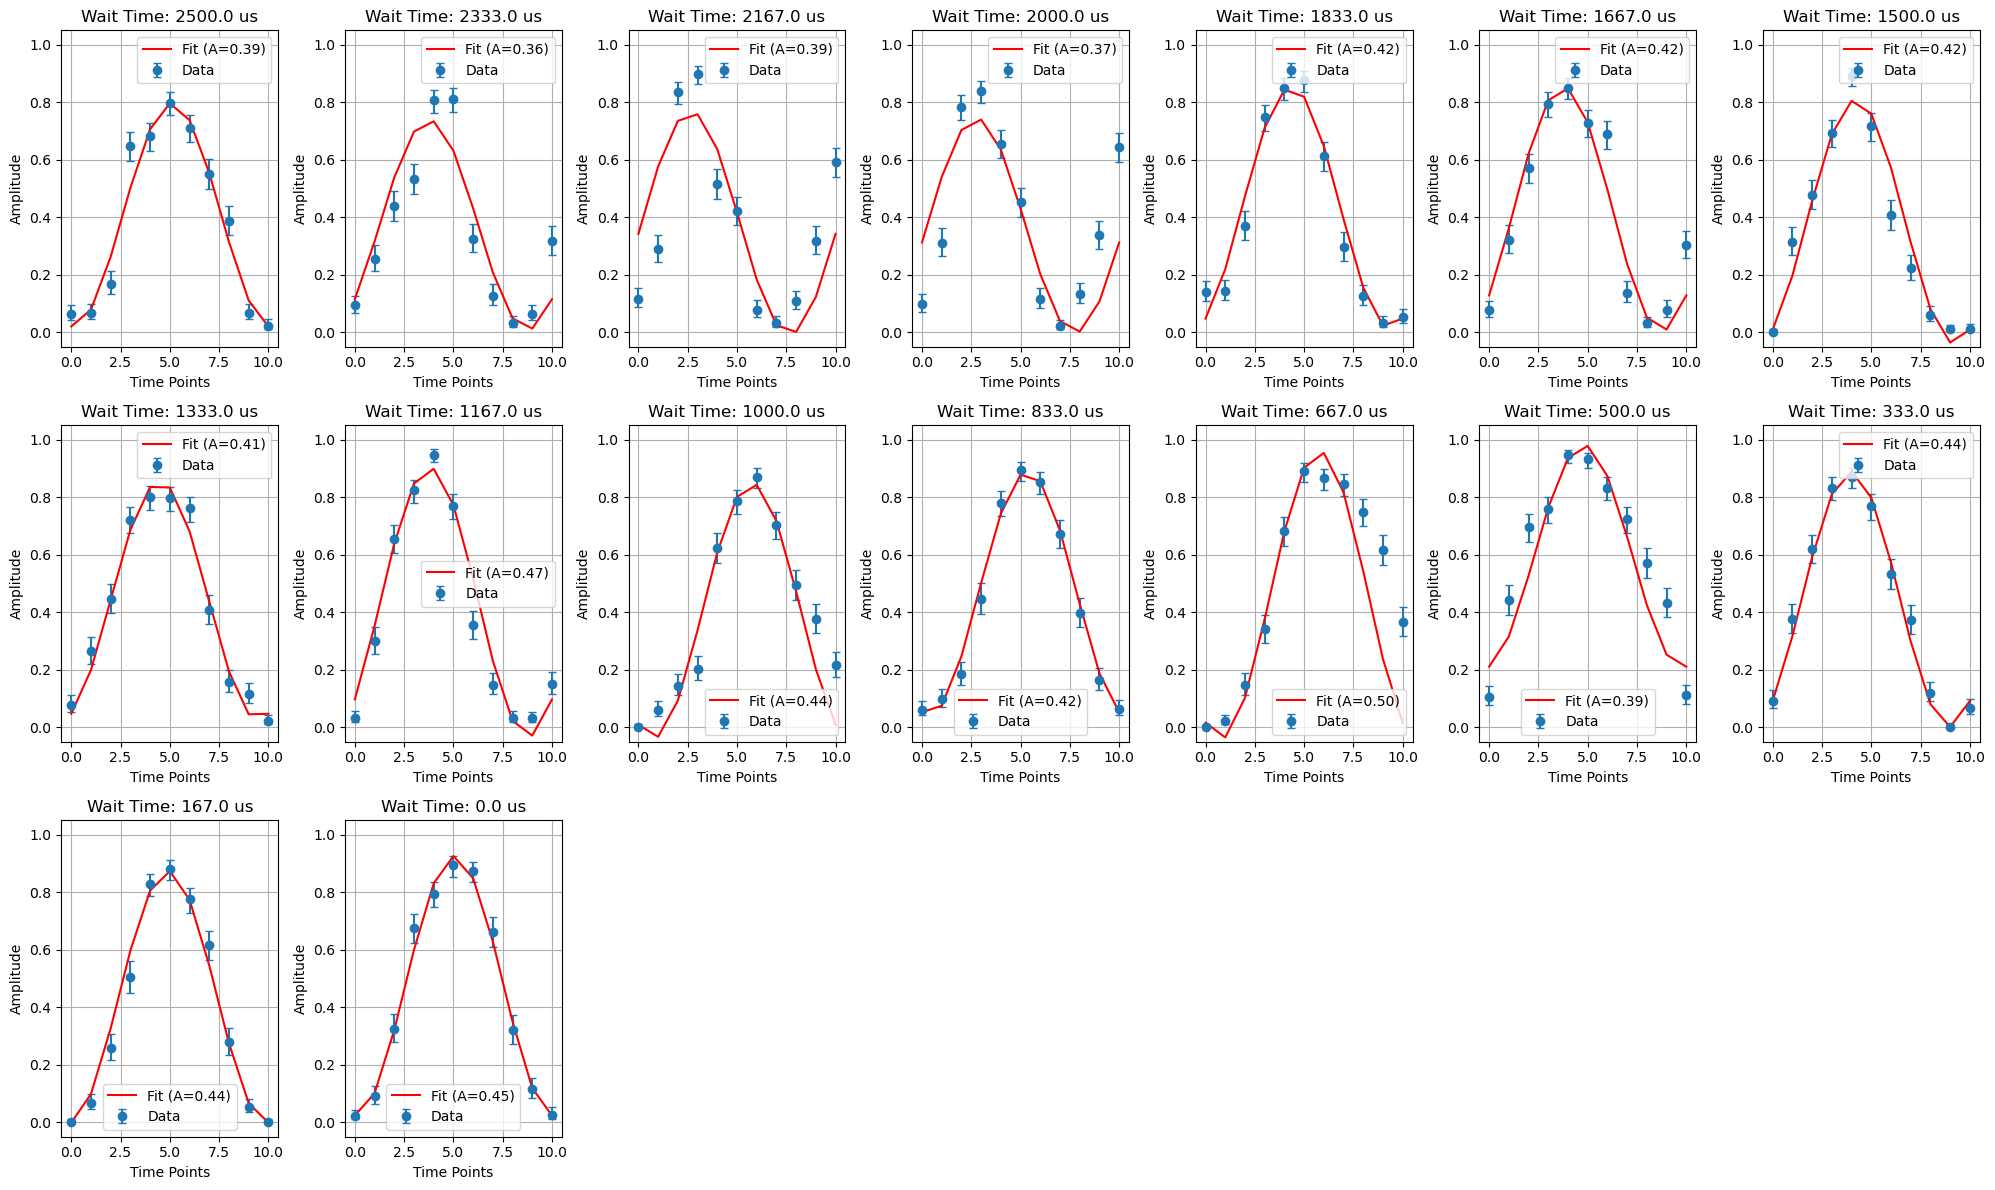


Fitted Results (Lists):
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.451, 0.034, 0.475
  Amplitude (2*|A|) = 0.903 ± 0.025
  Phase = 0.034 ± 0.044
Wait Time: 167.0 us
  Params (A, phi, offset) = 0.438, 6.220, 0.436
  Amplitude (2*|A|) = 0.876 ± 0.022
  Phase = 6.220 ± 0.042
Wait Time: 333.0 us
  Params (A, phi, offset) = 0.444, 5.633, 0.445
  Amplitude (2*|A|) = 0.889 ± 0.022
  Phase = 5.633 ± 0.042
Wait Time: 500.0 us
  Params (A, phi, offset) = 0.388, 6.144, 0.595
  Amplitude (2*|A|) = 0.775 ± 0.027
  Phase = 6.144 ± 0.051
Wait Time: 667.0 us
  Params (A, phi, offset) = 0.500, 0.481, 0.460
  Amplitude (2*|A|) = 1.000 ± 0.023
  Phase = 0.481 ± 0.031
Wait Time: 833.0 us
  Params (A, phi, offset) = 0.424, 0.228, 0.466
  Amplitude (2*|A|) = 0.848 ± 0.027
  Phase = 0.228 ± 0.046
Wait Time: 1000.0 us
  Params (A, phi, offset) = 0.444, 0.467, 0.405
  Amplitude (2*|A|) = 0.887 ± 0.026
  Phase = 0.467 ± 0.038
Wait Time: 1167.0 us
  Params (A, phi, offset) = 0.468, 5.519, 0.435
  Amplitude

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi/10 * t - phi - np.pi) + offset

def fit_sine_curve(ket_data, lower_error, upper_error):
    if len(ket_data) == 5:
        t = 2*np.arange(len(ket_data))
    else:
        t = np.arange(len(ket_data))
    valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    t_valid = t[valid_indices]
    ket_data_valid = np.array(ket_data)[valid_indices]
    lower_error_valid = np.array(lower_error)[valid_indices]
    upper_error_valid = np.array(upper_error)[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid))/2
    A0 = np.clip(A0, 0.0, 0.5)
    initial_guess = [0.44, np.pi, 0.46]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, 0, 0], [0.5, 2*np.pi*0.99, 1])
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list,
                                        ket_data_list,
                                        lower_error_list,
                                        upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []
    
    for i in range(len(wait_time_list)):
        wt = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]
        
        if len(kd) > 4:
            params, errors = fit_sine_curve(kd, le, ue)
            if params is not None and errors is not None and errors[0] is not None:
                A, phi, offset = params
                amplitude = 2.0 * abs(A)
                amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
                phase_error = errors[1]

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(amplitude)
                fit_amplitude_errors_list.append(amplitude_error)
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(phase_error)
        else:
            fit_wait_times_list.append(wt)
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)
    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )

def plot_sine_fits_in_lists(wait_time_list,
                            ket_data_list,
                            lower_error_list,
                            upper_error_list,
                            fit_wait_times_list,
                            fit_params_list):
    num_plots = len(wait_time_list)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(num_plots):
        wt = wait_time_list[::-1][i]
        kd = ket_data_list[::-1][i]
        le = lower_error_list[::-1][i]
        ue = upper_error_list[::-1][i]
        
        t = np.arange(len(kd))
        ax = axes[i]
        ax.errorbar(
            t,
            kd,
            yerr=[abs(le), abs(ue)],
            fmt='o',
            label='Data',
            capsize=3
        )
        
        if wt in fit_wait_times_list:
            # NOTE: keeping your original indexing approach unchanged
            j = fit_wait_times_list[::-1].index(wt)
            A, phi, offset = fit_params_list[::-1][i]
            if A is not None:
                fit_curve = sine_function(t, A, phi, offset)
                ax.plot(t, fit_curve, color='red', label=f'Fit (A={A:.2f})')

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Time Points')
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Amplitude')
        ax.grid()
        ax.legend()
    
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.savefig('laser_noise_phase_scans.png', dpi=300)
    plt.show()

# --------------------------------------------------------------------
# ONLY PLUMBING CHANGE:
# Use Cell 2 outputs: processed_wait_times, ket_data_list, ...
# --------------------------------------------------------------------
wait_time_list_for_fit = processed_wait_times

(
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_all_wait_times_to_sine_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_sine_fits_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results (Lists):")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]
    print(f"Wait Time: {wt} us")
    print(f"  Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
    print(f"  Amplitude (2*|A|) = {amp:.3f} ± {amp_err:.3f}")
    print(f"  Phase = {phase:.3f} ± {phase_err:.3f}")


## Cell 4: Function to calculate phases accumulation due to line signal

In [21]:

def compute_phases_from_line_fit(
    pulse_train,
    fractions,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt",
    t_ref="start",  # "mid", "start", or "end"
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt",
    integral_scale=1.1, 
    LT_comp = False

):
    """
    Single-function version of your entire pipeline.

    Computes per-pulse phase corrections using:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (Gauss), so A(t) is in G*s.

    Phase per pulse i:
        phi_i = 2π * 1e6 * sens_i * A(t_i)

    Returns:
        phases_per_pulse (list[float]): same length as pulse_train
    """

    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(
                f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
            )
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    # -----------------------------
    # Main logic (formerly top-level)
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    # Build pulse schedule from pi-times
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # Sensitivities
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # Reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:  # "mid"
            t_refs[i] = 0.5 * (t_start + t_end)
    # print('trefs = ', t_refs)
    # Compute phases
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    detunings = np.zeros(len(pulse_train), dtype=float)
    # sys_detunings = [integral_scale/2, -integral_scale/2, 0, -integral_scale/2, integral_scale/2]
    # sys_detunings = [0, -integral_scale, 0, -integral_scale, 0]
    sys_detunings = [integral_scale, 0, 0, 0, integral_scale]
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue
        ti = float(t_refs[i])
        if not LT_comp:

            # print(ti)
            Bt = B_rel_G(ti, B0, A60, phi60, A180, phi180, param_file=param_file)
            I0t = integral_B_rel_G(0.0, ti, B0, A60, phi60, A180, phi180, param_file=param_file)
            area_Gs = 0*ti * Bt - I0t #+ ti*integral_scale

            phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs + 2*np.pi*sys_detunings[i] * ti
            detunings[i] = Bt * sens_array[i]
        else:
            phases_per_pulse[i] = 2*np.pi*sys_detunings[i] * ti
    return phases_per_pulse.tolist(), sens_array

In [22]:
PHASES_PER_PULSE, sens = compute_phases_from_line_fit([[0,1,1], [0,2,0], [0,0,0], [0,2,0], [0, 1, 1]], [0.5, 1, 0, 1, 0.5])
print('ph = ', PHASES_PER_PULSE)
print(sens)

ph =  [0.0, -1.1896797828793425e-08, 0.0, -5.386297472613474e-08, -0.00723826270204223]
[3.16858205e+00 4.05898390e-05 0.00000000e+00 4.05898390e-05
 3.16858205e+00]


### Function to call phase calculations for different wait times

In [23]:
import numpy as np

def compute_theory_phase_mod_and_sens(
    max_waittime_us,
    target_transition,
    step_us=100,
    pi_t=np.array([21.48, 33.79, 108.27, 26.98, 35.26]),
    integral_scale=1.1,
    LT_comp = False
):

    # Build pulse train: [t1, t2, idle, t2, t1]
    t1 = target_transition[0]
    t2 = target_transition[1]
    pulse_train = [t1, t2, [0, 0, 0], t2, t1]

    accm_phase = []
    sens_list = None  # store once (should be constant for fixed pulse_train)

    # Use max_waittime_us instead of hard-coded 2200
    # step_us = max_waittime_us/100
    for i in np.linspace(0, max_waittime_us, 100):
        fractions = [0.5, 1, (np.sin((i / 1e6) * (np.pi / 2)))**2, 1, 0.5]

        phases, sens = compute_phases_from_line_fit(
            pulse_train,
            fractions,
            pi_t=pi_t,
            integral_scale=integral_scale,
            LT_comp = LT_comp
        )

        # Save sens as a proper list (you said you'll need this later)
        if sens_list is None:
            sens_list = list(np.array(sens, dtype=float))

        accm_phase.append(-phases[3] + phases[4])

    theory_phases = np.mod(np.array(accm_phase), 2*np.pi) / np.pi
    return theory_phases, sens_list


In [24]:
max_waittime_us = max(wait_time_list)  # from Cell 2 input list (or use processed_wait_times if preferred)

theory_phases, sens_list = compute_theory_phase_mod_and_sens(
    max_waittime_us=max_waittime_us,
    target_transition=target_transitions,   # from Cell 1 (the pair you selected)
    step_us=100,
    integral_scale=1.1,  # you'll fit this later
)

print("theory_phases shape:", theory_phases.shape)
print("sens_list:", sens_list)


theory_phases shape: (100,)
sens_list: [np.float64(-2.4663025196787203), np.float64(4.0589839045424014e-05), np.float64(0.0), np.float64(4.0589839045424014e-05), np.float64(-2.4663025196787203)]


## Cell 5: Function to fit the calculated phase accumulation to experimental data

A normal residual would be:
$$
r_i = \phi^{\mathrm{exp}}_i - \phi^{\mathrm{th}}_i(s)
$$
But because phase wraps, $r_i$ must be taken as the **minimal angular difference** in $[-\pi, \pi]$.
That is computed by:
$$
\Delta\phi_i(s)
= \operatorname{wrap}_{[-\pi,\pi]}!\left(\phi^{\mathrm{exp}}_i - \phi^{\mathrm{th}}_i(s)\right)
$$
A convenient and numerically stable way to do that is:
$$
\Delta\phi_i(s)
=
\arg\left(e^{i(\phi^{\mathrm{exp}}_i - \phi^{\mathrm{th}}_i(s))}\right)
$$
This returns the signed smallest-angle difference, automatically accounting for wraparound.
You then weight these circular residuals by the phase uncertainties:
$$
\chi^2(s)
=
\sum_{i}
\left(\frac{\Delta\phi_i(s)}{\sigma_i}\right)^2
$$
This is “$\chi^2$-like” because it has the standard weighted least-squares form, but uses the **circular residual** $\Delta\phi$ instead of an ordinary linear difference.


In [34]:
import numpy as np
from scipy.optimize import minimize_scalar

def fit_integral_scale_circular_payload(
    wait_times_list,
    fit_phases_list,
    fit_phase_errors_list,
    target_transitions,
    compute_phases_from_line_fit,   # <-- pass the function itself
    bounds=(-100, 100),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0.0,
    LT_comp=False,
    pi_t=np.array([21.48, 33.79, 108.27, 26.98, 35.26]),
):
    """
    Simplified fitter:
      - theory computed directly at experimental wait times (no linspace grid)
      - keeps your weighted_circular_chi2 definition
      - returns same payload keys as before
    """

    # -----------------------------
    # 1) Build experimental arrays
    # -----------------------------
    exp_wait = np.array(wait_times_list, dtype=float)
    exp_phi = np.array([p if p is not None else np.nan for p in fit_phases_list], dtype=float)
    exp_phi_err = np.array([e if e is not None else np.nan for e in fit_phase_errors_list], dtype=float)

    valid = np.isfinite(exp_wait) & np.isfinite(exp_phi) & np.isfinite(exp_phi_err)
    exp_wait = exp_wait[valid]
    exp_phi = exp_phi[valid]
    exp_phi_err = exp_phi_err[valid]

    if exp_wait.size < 3:
        raise ValueError("Not enough valid experimental phase points to fit integral_scale.")

    # Keep a stable order (important for any unwrapping / consistent evaluation)
    order = np.argsort(exp_wait)
    exp_wait = exp_wait[order]
    exp_phi = exp_phi[order]
    exp_phi_err = exp_phi_err[order]

    # store in your plotting convention (mod 2pi)/pi
    exp_phase_mod = np.mod(exp_phi, 2*np.pi) / np.pi
    exp_phase_mod_err = exp_phi_err / np.pi

    # -----------------------------
    # 2) Theory at experimental wait times (integrated here)
    # -----------------------------
    t1 = target_transitions[0]
    t2 = target_transitions[1]
    pulse_train = [t1, t2, [0, 0, 0], t2, t1]

    # Cache to avoid recomputing theory for the same scale repeatedly
    theory_cache = {}  # scale -> (phi_at_exp, sens_list)
    wait_grid_dense = np.linspace(0, max(exp_wait), 100)
    # def theory_phi_radians_at_exp(scale, use_exp = True):

    #     key = float(scale)
    #     if key in theory_cache:
    #         return theory_cache[key][0]

    #     accm_phase = []
    #     sens_list = None

    #     # compute at each experimental wait time (us)
        
    #     if use_exp:
    #         times_list = exp_wait
    #     else:
    #         times_list = wait_grid_dense

    #     if not use_exp:
    #         print(use_exp)
    #         print(len(times_list))
    #     for w_us in times_list:
    #         # keep your fraction definition exactly
    #         fractions = [0.5, 1, (np.sin((w_us / 1e6) * (np.pi / 2)))**2, 1, 0.5]

    #         phases, sens = compute_phases_from_line_fit(
    #             pulse_train,
    #             fractions,
    #             pi_t=pi_t,
    #             integral_scale=scale,
    #             LT_comp=LT_comp
    #         )

    #         if sens_list is None:
    #             sens_list = list(np.array(sens, dtype=float))

    #         accm_phase.append(-phases[3] + phases[4])

    #     phi_at_exp = np.array(accm_phase, dtype=float)  # radians (unwrapped raw)
    #     theory_cache[key] = (phi_at_exp, sens_list)
    #     return phi_at_exp
    def theory_phi_radians_at_exp(scale, use_exp=True):
        key = (float(scale), bool(use_exp))
        if key in theory_cache:
            return theory_cache[key][0]

        accm_phase = []
        sens_list = None

        times_list = exp_wait if use_exp else wait_grid_dense

        for w_us in times_list:
            fractions = [0.5, 1, (np.sin((w_us / 1e6) * (np.pi / 2)))**2, 1, 0.5]
            phases, sens = compute_phases_from_line_fit(
                pulse_train, fractions, pi_t=pi_t, integral_scale=scale, LT_comp=LT_comp
            )
            if sens_list is None:
                sens_list = list(np.array(sens, dtype=float))
            accm_phase.append(-phases[3] + phases[4])

        phi_out = np.array(accm_phase, dtype=float)
        theory_cache[key] = (phi_out, sens_list)
        return phi_out
    # -----------------------------
    # 3) Objective: (your exact structure)
    # -----------------------------
    def weighted_circular_chi2(scale):
        phi_th_at_exp = theory_phi_radians_at_exp(scale)
        dphi = np.angle(np.exp(1j * (exp_phi - phi_th_at_exp)))

        sigma = np.copy(exp_phi_err)
        good = np.isfinite(sigma) & (sigma > 0)
        if np.any(~good):
            repl = np.nanmedian(sigma[good]) if np.any(good) else 1.0
            sigma[~good] = repl
        # sigma = 1
        return float(np.sum((dphi / sigma) ** 2))

    # -----------------------------
    # 4) Fit integral_scale
    # -----------------------------
    res = minimize_scalar(
        weighted_circular_chi2,
        bounds=bounds,
        method="bounded",
        options={"xatol": xatol, "maxiter": maxiter},
    )
    best_scale = float(res.x)
    fit_objective = float(res.fun)

    # -----------------------------
    # 5) Uncertainty via local curvature
    # -----------------------------
    h = max(10 * xatol, 1e-8)
    a, b = bounds
    s0 = best_scale
    s_minus = max(a, s0 - h)
    s_plus  = min(b, s0 + h)

    if s_minus == s0 or s_plus == s0:
        h2 = max(100 * xatol, 1e-7)
        s_minus = max(a, s0 - h2)
        s_plus  = min(b, s0 + h2)

    chi0 = weighted_circular_chi2(s0)
    chim = weighted_circular_chi2(s_minus)
    chip = weighted_circular_chi2(s_plus)

    h1 = s0 - s_minus
    h2 = s_plus - s0
    chi2_dd = 2.0 * (((chip - chi0) / h2) - ((chi0 - chim) / h1)) / (h1 + h2)

    if not np.isfinite(chi2_dd) or chi2_dd <= 0:
        best_scale_err = 0.0
    else:
        best_scale_err = float(np.sqrt(2.0 / chi2_dd))

    # -----------------------------
    # 6) Build theory “curves” for payload (use exp_wait grid)
    # -----------------------------
    # ref
    print(f'doing ref {LT_comp}')
    phi_ref = theory_phi_radians_at_exp(ref_int_scale,use_exp=False)  # compute on dense grid for smoothness, but will be interpolated onto exp_wait later
    # best
    print(f'doing best {LT_comp}')
    phi_fit = theory_phi_radians_at_exp(best_scale,use_exp=False)  # compute on dense grid for smoothness, but will be interpolated onto exp_wait later
    # sens_list from best (cached)
    # sens_list = theory_cache[float(best_scale)][1] if float(best_scale) in theory_cache else None
    # sens_list from best (cached)  <-- REPLACE YOUR CURRENT LINE WITH THIS BLOCK
    best_key = (float(best_scale), True)
    alt_key  = (float(best_scale), False)

    if best_key in theory_cache:
        sens_list = theory_cache[best_key][1]
    elif alt_key in theory_cache:
        sens_list = theory_cache[alt_key][1]
    else:
        _ = theory_phi_radians_at_exp(best_scale, use_exp=True)
        sens_list = theory_cache[(float(best_scale), True)][1]

    payload = {
        "LT_comp": bool(LT_comp),
        "target_transitions": target_transitions,
        "max_waittime_us": float(np.max(exp_wait)),

        "best_scale": best_scale,
        "best_scale_err": best_scale_err,
        "fit_objective": fit_objective,
        "ref_int_scale": float(ref_int_scale),

        "exp_wait_us": exp_wait,
        "exp_phase_mod_over_pi": exp_phase_mod,
        "exp_phase_mod_err_over_pi": exp_phase_mod_err,

        # keep keys same as before:
        "theory_wait_us": wait_grid_dense,
        "theory_ref_phase_mod_over_pi": np.mod(phi_ref, 2*np.pi) / np.pi,
        "theory_fit_phase_mod_over_pi": np.mod(phi_fit, 2*np.pi) / np.pi,

        "sens_list": list(np.array(sens_list, dtype=float))}

    return payload

In [35]:
payload_F = fit_integral_scale_circular_payload(    
    fit_phases_list=fit_phases_list,
    fit_phase_errors_list=fit_phase_errors_list,
    wait_times_list=wait_time_list,
    target_transitions=target_transitions,
    compute_phases_from_line_fit=compute_phases_from_line_fit,
    bounds=(-50, 50),
    ref_int_scale=0, LT_comp=False)
payload_T = fit_integral_scale_circular_payload(    wait_times_list=wait_time_list,
    fit_phases_list=fit_phases_list,
    fit_phase_errors_list=fit_phase_errors_list,
    target_transitions=target_transitions,
    compute_phases_from_line_fit=compute_phases_from_line_fit,
    bounds=(-50, 50),
    ref_int_scale=0, LT_comp=True)

# then in your plot function:
# - plot payload_F["exp_*"] once (they should be the same if same data)
# - overlay payload_F["theory_*"] and payload_T["theory_*"]

doing ref False
doing best False
doing ref True
doing best True


In [36]:
print(payload_F)

print(payload_T)

{'LT_comp': False, 'target_transitions': [[0, 4, -1], [0, 2, 0]], 'max_waittime_us': 2500.0, 'best_scale': -49.99999814878308, 'best_scale_err': 1.0146246187936767, 'fit_objective': 19636.164845619405, 'ref_int_scale': 0.0, 'exp_wait_us': array([   0.,  167.,  333.,  500.,  667.,  833., 1000., 1167., 1333.,
       1500., 1667., 1833., 2000., 2167., 2333., 2500.]), 'exp_phase_mod_over_pi': array([0.01074236, 1.98      , 1.79314645, 1.95572307, 0.15313226,
       0.07273247, 0.1486483 , 1.7566152 , 1.89761586, 1.84590992,
       1.75079238, 1.86992009, 1.55049997, 1.53079628, 1.75058505,
       0.02207638]), 'exp_phase_mod_err_over_pi': array([0.01400353, 0.01321933, 0.01332029, 0.01623308, 0.00987726,
       0.01464724, 0.01223774, 0.01022119, 0.01481305, 0.00952281,
       0.01247076, 0.01367724, 0.01386811, 0.0132745 , 0.01472945,
       0.01520081]), 'theory_wait_us': array([   0.        ,   25.25252525,   50.50505051,   75.75757576,
        101.01010101,  126.26262626,  151.51515152

# A Call to Pipeline and update log

In [66]:
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt

def _to_pm1(y_mod2_over_pi):
    """Map [0,2) -> [-1,1) in units of pi."""
    y = np.asarray(y_mod2_over_pi, dtype=float)
    return ((y + 1.0) % 2.0) - 1.0

def _unwrap_over_pi(y_pm1_over_pi):
    """Unwrap in radians then convert back to units of pi."""
    y = np.asarray(y_pm1_over_pi, dtype=float)
    return np.unwrap(y * np.pi) / np.pi

def plot_bussed_ramsey_payloads(payloads, title=None, show_ref=True):
    if not payloads:
        raise ValueError("payloads is empty")

    p0 = payloads[0]
    if title is None:
        tt = p0["target_transitions"]
        title = f"{tt[0]} → {tt[1]} (bussed Ramsey)"

    fig, ax = plt.subplots(figsize=(20, 10))

    # consistent colors
    cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0', 'C1'])
    color_false = cycle[0]
    color_true  = cycle[1]

    def color_for(p):
        return color_true if p.get("LT_comp", False) else color_false

    for p in payloads:
        LT = bool(p.get("LT_comp", False))
        tag = "Compensated" if LT else "Uncompensated"
        c = color_for(p)

        # ---- EXP: sort, map to [-1,1), unwrap ----
        x = np.asarray(p["exp_wait_us"], dtype=float)
        y = np.asarray(p["exp_phase_mod_over_pi"], dtype=float)          # expected in [0,2)
        yerr = np.asarray(p["exp_phase_mod_err_over_pi"], dtype=float)

        order = np.argsort(x)
        x, y, yerr = x[order], y[order], yerr[order]

        y_pm1 = _to_pm1(y)
        y_unw = _unwrap_over_pi(y_pm1)

        ax.errorbar(
            x, y_unw, yerr=yerr,
            fmt="o", capsize=3,
            color=c, ecolor=c,
            label=f"Experiment ({tag})", markersize=8, elinewidth=1.5, alpha=0.75
        )

        # ---- THEORY: sort, map to [-1,1), unwrap ----
        xt = np.asarray(p["theory_wait_us"], dtype=float)
        yref = np.asarray(p["theory_ref_phase_mod_over_pi"], dtype=float)  # expected in [0,2)
        yfit = np.asarray(p["theory_fit_phase_mod_over_pi"], dtype=float)  # expected in [0,2)

        torder = np.argsort(xt)
        xt, yref, yfit = xt[torder], yref[torder], yfit[torder]

        yref_unw = _unwrap_over_pi(_to_pm1(yref))
        yfit_unw = _unwrap_over_pi(_to_pm1(yfit))

        if show_ref:
            ax.plot(
                xt, yref_unw, "--",
                color=c,
                label=f"Theory ref ({tag}, detuning={np.round(p['ref_int_scale'], 2)})", linewidth=1.5
            )
        ax.plot(
            xt, yfit_unw, "-",
            color=c,
            label=f"Theory fit ({tag}, \n detuning={np.round(p['best_scale'], 2)} ± {np.round(p['best_scale_err'], 2)})", linewidth=1.5
        )

    ax.set_xlabel("Wait time (us)", fontsize=14)
    ax.set_ylabel("Phase (/π)", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.grid(True)

    # legend outside
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0, fontsize=14)
    fig.tight_layout()
    plt.savefig(f"{tt[0]}_{tt[1]}_bussed_ramsey_compensation.png", dpi=300, bbox_inches='tight')
    plt.show()

def run_full_bussed_ramsey_pipeline_readonly(
    target_transitions,
    log_path,
    directory_path,
    Z_drive_raw_data,
    step_us=100,
    do_plot=False,
    fit_bounds=(-100, 100),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0.0,
    LT_comp_mode=False,   # False / True / "both"
    theory_npts=200
):
    """
    Read-only orchestrator. Does NOT modify the log file.

    Requires these functions already defined in your notebook:
      - parse_log_file_for_pair(log_path, target_transitions, LT_comp)
      - search_files_by_transitions(directory, target_transitions, target_date_times)
      - process_all_wait_times_in_lists(...)
      - fit_all_wait_times_to_sine_in_lists(...)
      - compute_theory_phase_mod_and_sens(...)
      - fit_integral_scale_circular_payload(...)

    Returns:
      - if single mode: payload dict
      - if both: dict {False: payload_false, True: payload_true}
    """

    # normalize mode
    if isinstance(LT_comp_mode, str) and LT_comp_mode.strip().lower() in ["both", "true+false", "false+true"]:
        modes = [False, True]
    else:
        modes = [bool(LT_comp_mode)]

    # Determine ket ordering once
    ket_1_first = (target_transitions[0][1:] == target_transitions[1][1:])

    # Ensure search_files_by_transitions sees correct raw-data base path
    globals()["Z_drive_raw_data"] = Z_drive_raw_data

    payloads = {}

    for LT_comp in modes:
        # 1) Read datetimes from log for this LT_comp choice
        target_date_times, mean_dev = parse_log_file_for_pair(log_path, target_transitions, LT_comp)
        print(target_date_times)
        if len(target_date_times) == 0:
            raise ValueError(f"No datetimes found in log for {target_transitions} with LT_comp={LT_comp}")

        # 2) Find matching PD files
        wait_time_list, raw_file_paths_list, final_transitions = search_files_by_transitions(
            directory_path, target_transitions, target_date_times
        )
        if len(wait_time_list) == 0:
            raise ValueError(f"No PD files matched transitions+datetimes for LT_comp={LT_comp}")

        # 3) Process PD -> time series
        processed_wait_times, ket_data_list, lower_error_list, upper_error_list = process_all_wait_times_in_lists(
            wait_time_list, raw_file_paths_list, ket_1_first
        )

        # 4) Sine fit -> experimental phases
        (
            fit_wait_times_list,
            fit_params_list,
            fit_amplitudes_list,
            fit_amplitude_errors_list,
            fit_phases_list,
            fit_phase_errors_list,
        ) = fit_all_wait_times_to_sine_in_lists(
            processed_wait_times,
            ket_data_list,
            lower_error_list,
            upper_error_list,
        )
        fit_phase_errors_list = np.sqrt(np.array(fit_phase_errors_list, dtype=float)**2 + (2*np.pi * mean_dev * np.array(fit_wait_times_list, dtype=float)*1e-6)**2)
        # 5) Theory fit -> payload
        if LT_comp:
            fit_bounds = (-100, 100)
        else:
            fit_bounds = (-100, 100)
        payload = fit_integral_scale_circular_payload(
            wait_times_list=fit_wait_times_list,
            fit_phases_list=fit_phases_list,
            fit_phase_errors_list=fit_phase_errors_list,
            target_transitions=target_transitions,
            compute_phases_from_line_fit=compute_phases_from_line_fit,
            bounds=fit_bounds,
            xatol=xatol,
            maxiter=maxiter,
            ref_int_scale=ref_int_scale,
            LT_comp=LT_comp,
        )
        print(payload)
        # compute the same sens_value you were using
        sens_arr = np.array(payload["sens_list"], dtype=float)
        payload["sens_value"] = float(sens_arr[4] - sens_arr[3])

        # store mean deviation from log (handy later)
        payload["mean_deviation_hz"] = mean_dev

        payloads[LT_comp] = payload

    # optional overlay plot
    if do_plot:
        plot_bussed_ramsey_payloads([payloads[m] for m in modes])

    # return shape
    if len(modes) == 1:
        return payloads[modes[0]]
    else:
        return payloads

{datetime.datetime(2026, 2, 21, 11, 51)}
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[97, 95, 98, 96, 99, 96, 95, 96, 94, 96, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[92, 94, 94, 95, 93, 95, 93, 92, 91, 93, 94]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[91, 92, 89, 91, 93, 90, 98, 91, 88, 92, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[96, 90, 90, 90, 91, 93, 87, 93, 84, 91, 94]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[91, 92, 94, 86, 92, 87, 85, 87, 94, 96, 89]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[81, 86, 92, 88, 85, 92, 92, 93, 87, 90, 89]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[87, 83, 87, 80, 90, 94, 84, 86

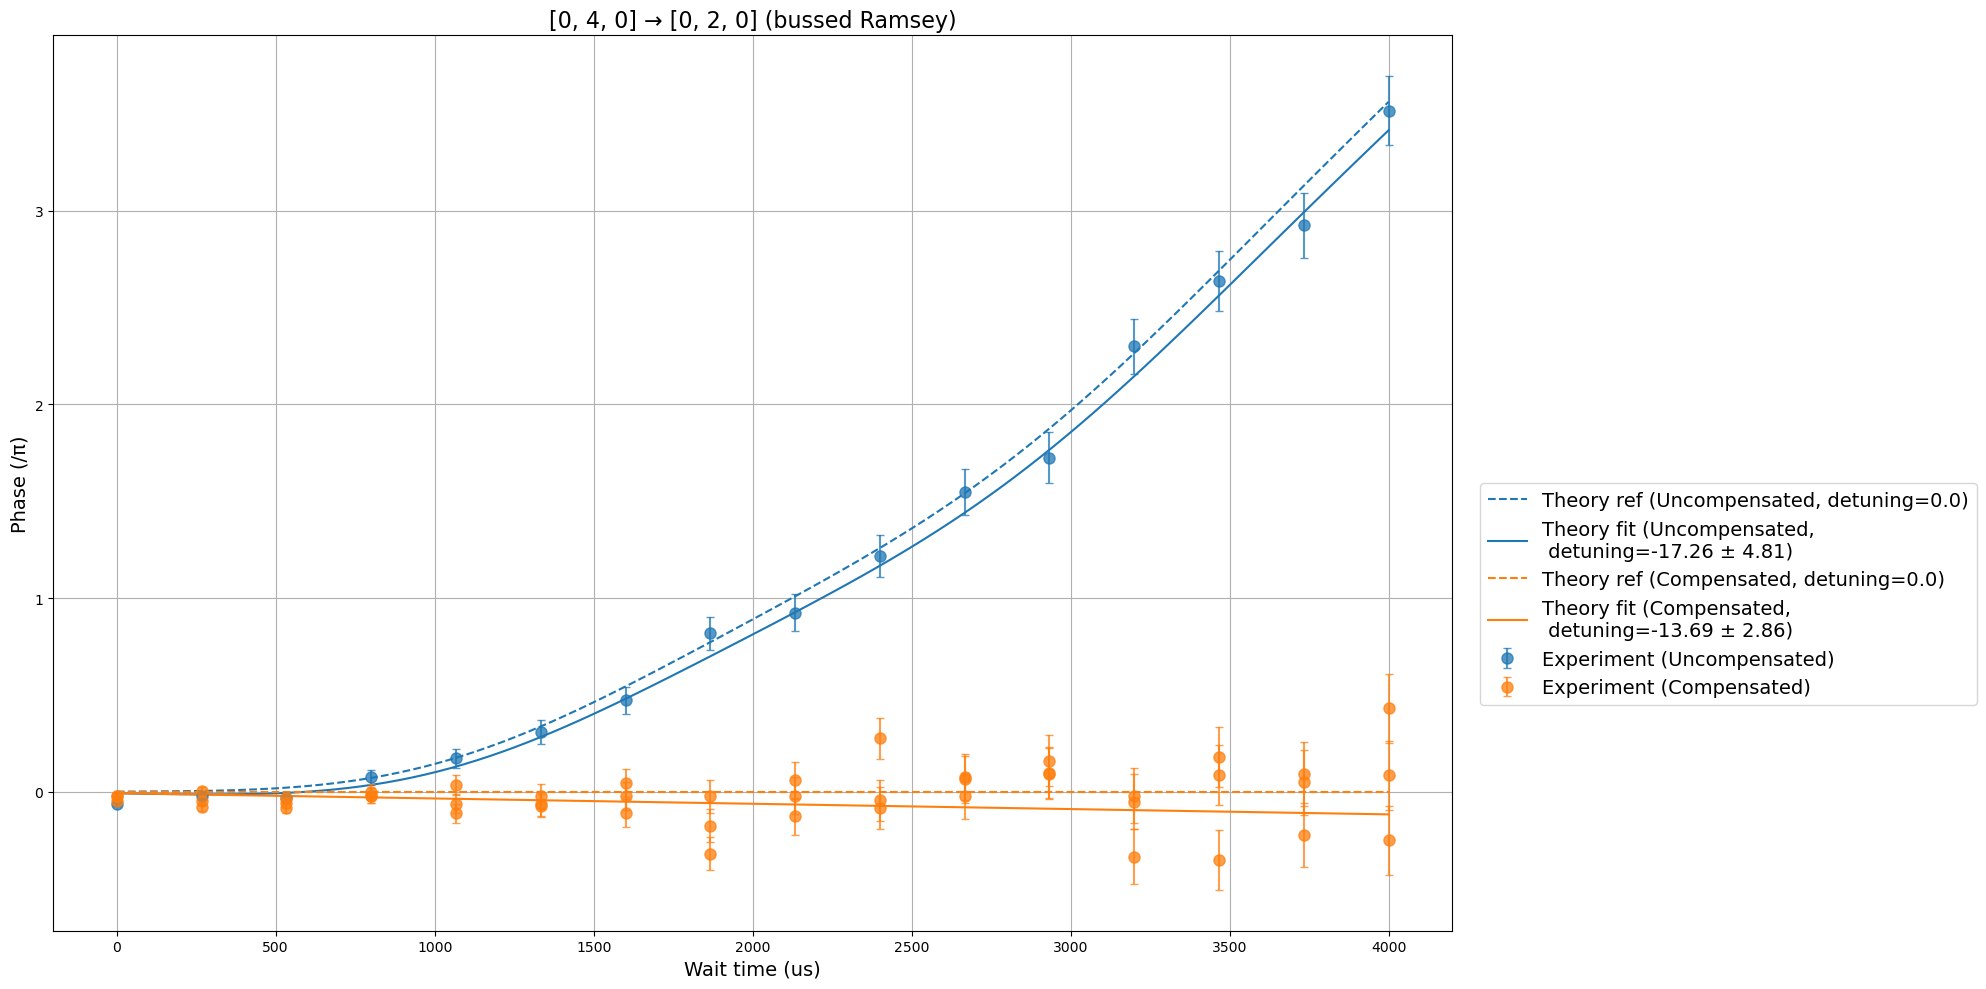

In [89]:
payloads = run_full_bussed_ramsey_pipeline_readonly(
    target_transitions=[[0,4,0],[0,2,0]],
    log_path=log_path,
    directory_path=directory_path,
    Z_drive_raw_data=Z_drive_raw_data,
    LT_comp_mode="both",
    do_plot=True
)

# access results:
payload_false = payloads[False]
payload_true  = payloads[True]

In [83]:
import re
from pathlib import Path

# Matches a transition like: [[0, 3, -1], [0, 2, 0]]
TRANSITION_RE = re.compile(r'(\[\[\s*-?\d+\s*,\s*-?\d+\s*,\s*-?\d+\s*\]\s*,\s*\[\s*-?\d+\s*,\s*-?\d+\s*,\s*-?\d+\s*\]\s*\])')

# Matches datetime strings like: 20260220_1446
DT_RE = re.compile(r'\b\d{8}_\d{4}\b')

def transitions_with_datetimes(filepath: str):
    text = Path(filepath).read_text(encoding="utf-8", errors="replace")

    results = []  # each item: {"transition": "...", "datetimes": [...], "line": <int>}
    for lineno, line in enumerate(text.splitlines(), start=1):
        m = TRANSITION_RE.search(line)
        if not m:
            continue

        transition_str = m.group(1)
        datetimes = DT_RE.findall(line)

        if datetimes:
            results.append(
                {
                    "transition": transition_str,
                    "datetimes": sorted(set(datetimes)),
                    "line": lineno,
                }
            )

    # If you only want unique transitions (not repeated across lines), dedupe here:
    unique = {}
    for r in results:
        key = r["transition"]
        unique.setdefault(key, set()).update(r["datetimes"])
    unique_list = [{"transition": k, "datetimes": sorted(v)} for k, v in unique.items()]

    return unique_list, results

path = "Bussed_Ramsey_datetime_log.txt"

unique_list, per_line = transitions_with_datetimes(path)

print("Transitions that have datetimes associated with them:")
for item in unique_list:
    print(eval(item["transition"]))

Transitions that have datetimes associated with them:
[[0, 3, -1], [0, 2, 0]]
[[0, 3, 0], [0, 2, 0]]
[[0, 3, 1], [0, 2, 0]]
[[0, 3, 2], [0, 2, 0]]
[[0, 4, -1], [0, 2, 0]]
[[0, 4, 0], [0, 2, 0]]
[[0, 4, 1], [0, 2, 0]]


In [ ]:
for item in unique_list:
    print(f'Transition: {item["transition"]}')
    payloads = run_full_bussed_ramsey_pipeline_readonly(
        target_transitions=eval(item["transition"]),
        log_path=log_path,
        directory_path=directory_path,
        Z_drive_raw_data=Z_drive_raw_data,
        LT_comp_mode="both",
        do_plot=True
    )
    exp_wait_times = payloads[True]["exp_wait_us"] 
    exp_phases = payloads[True]["exp_phase_mod_over_pi"]
    exp_phases_pm1 = ((exp_phases + 1.0) % 2.0) - 1.0
    

Transition: [[0, 3, -1], [0, 2, 0]]
{datetime.datetime(2026, 2, 20, 14, 46), datetime.datetime(2026, 2, 20, 15, 15), datetime.datetime(2026, 2, 20, 15, 45), datetime.datetime(2026, 2, 20, 15, 25), datetime.datetime(2026, 2, 20, 16, 10)}
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[93, 95, 97, 94, 96, 95, 96, 94, 96, 97, 93]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[98, 91, 94, 88, 86, 91, 95, 89, 91, 92, 86]
Total sorted data points: 4400
Threshold recalculated using histogram: 13.5
(11, 100, 4)
13.5
[88, 91, 91, 88, 88, 89, 90, 92, 94, 91, 96]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[93, 92, 96, 99, 97, 97, 98, 100, 98, 96, 98]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[97, 98, 99, 98, 100, 99, 99, 100, 99, 97, 98]
Total sorted data points: 4400
Threshold recalculated using histo

c:\Users\iamga\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\iamga\anaconda3\Lib\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\iamga\AppData\Local\Temp\ipykernel_13408\690911711.py:95: RuntimeWarning: divide by zero encountered in divide
  upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
C:\Users\iamga\AppData\Local\Temp\ipykernel_13408\690911711.py:96: RuntimeWarning: divide by zero encountered in divide
  (1 + (num_SD**2 / exp_num))) + np.sqrt(
C:\Users\iamga\AppData\Local\Temp\ipykernel_13408\690911711.py:99: RuntimeWarning: divide by zero encountered in divide
  (num_SD**4 / (4 * exp_num**2))
C:\Users\iamga\AppData\Local\Temp\ipykernel_13408\690911711.py:100: RuntimeWarning: divide by zero encountered in divide
  ) / (1 + (num_SD**2 / exp_num))
C:\Users\iamga\AppData\Local\Te

Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[97, 97, 96, 99, 96, 97, 96, 93, 98, 100, 98]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[99, 95, 94, 95, 96, 92, 96, 96, 98, 95, 95]
Total sorted data points: 4400
Threshold recalculated using histogram: 9.5
(11, 100, 4)
9.5
[95, 93, 89, 88, 91, 92, 97, 96, 94, 98, 97]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[96, 94, 92, 93, 90, 84, 94, 94, 96, 91, 89]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[93, 96, 88, 91, 97, 92, 91, 89, 88, 87, 87]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[87, 98, 89, 86, 92, 89, 88, 88, 91, 92, 75]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[84, 94, 84, 89, 89, 88, 87, 84, 94, 87, 95]
Total sorted data points: 44

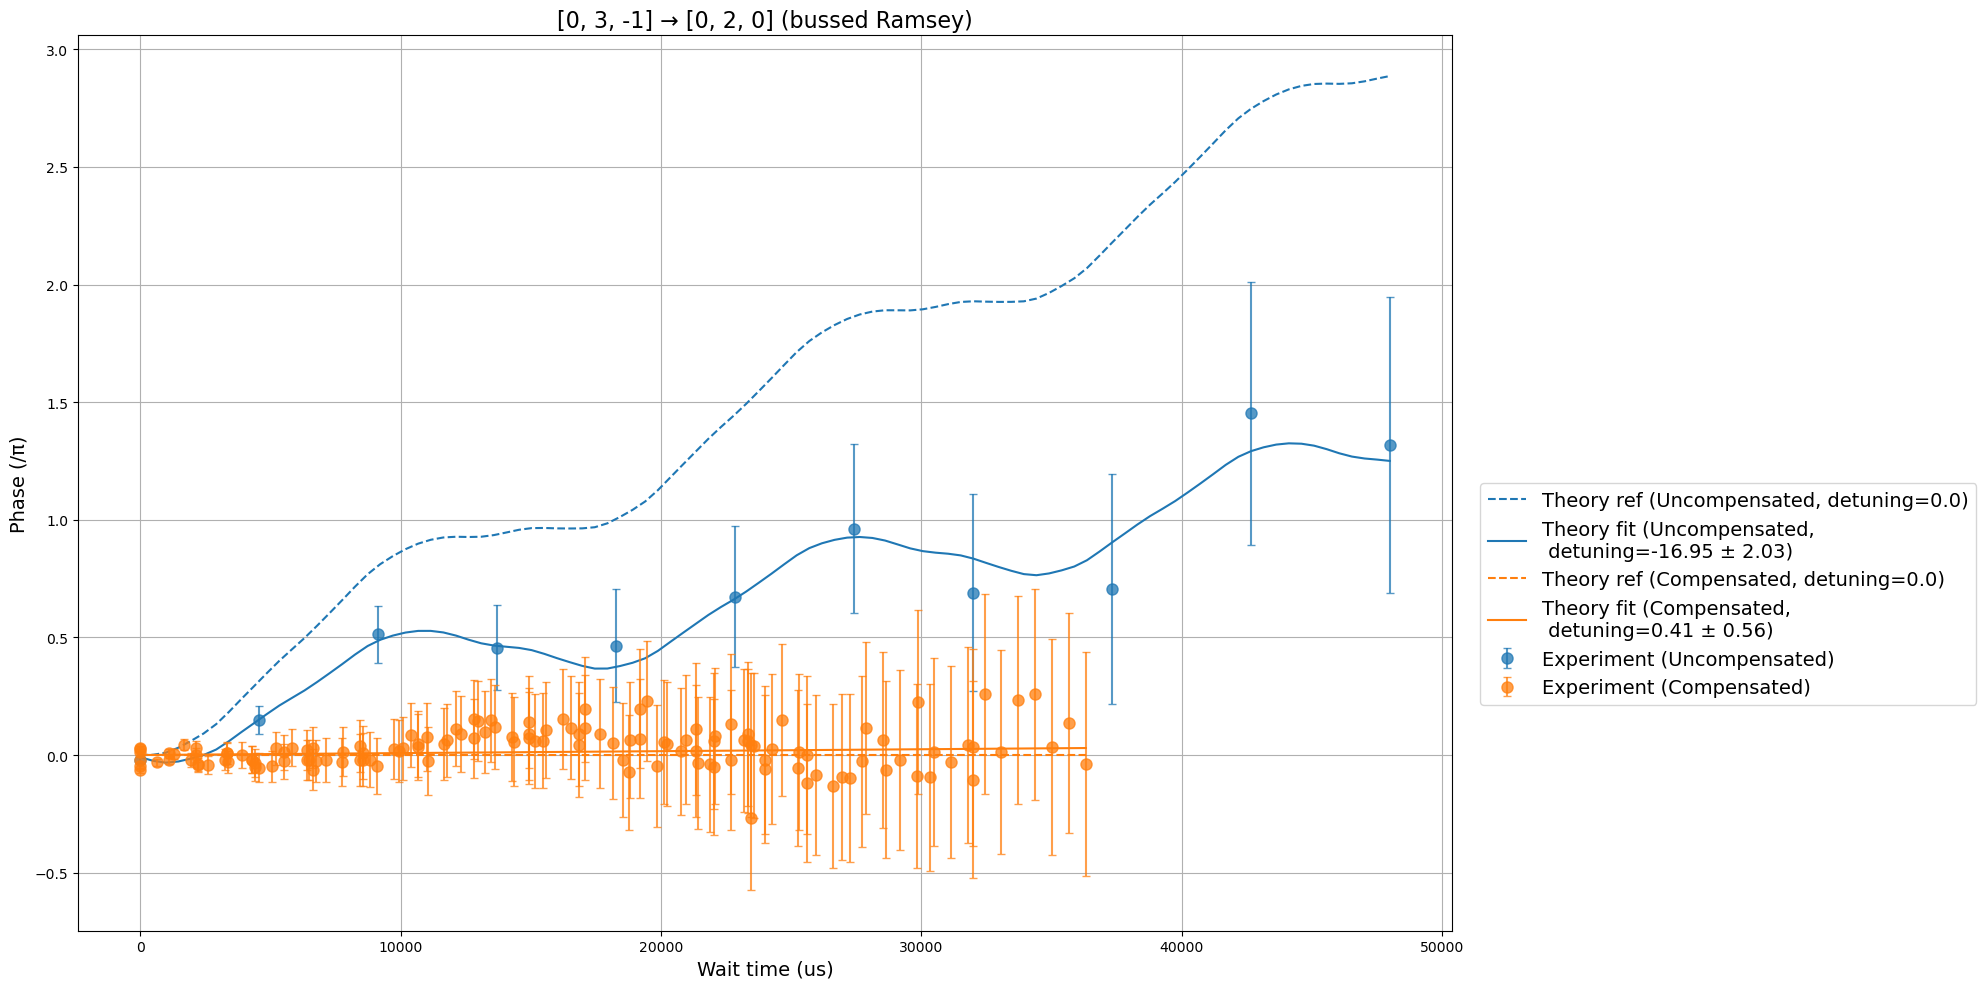

  saved -> Uncompensated_Phase_Data\((0,_3,_-1),_(0,_2,_0)).txt
Transition: [[0, 3, 0], [0, 2, 0]]
{datetime.datetime(2026, 2, 20, 18, 54), datetime.datetime(2026, 2, 20, 18, 19)}
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[84, 88, 87, 91, 89, 89, 84, 86, 87, 89, 86]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[99, 97, 93, 93, 96, 95, 94, 95, 95, 91, 93]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[91, 92, 94, 95, 93, 91, 93, 96, 92, 91, 91]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[89, 86, 86, 95, 93, 88, 92, 93, 88, 92, 86]
Total sorted data points: 4400
Threshold recalculated using histogram: 13.5
(11, 100, 4)
13.5
[92, 90, 95, 88, 91, 89, 91, 91, 84, 90, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[83, 87, 90, 88, 87, 91, 91, 85

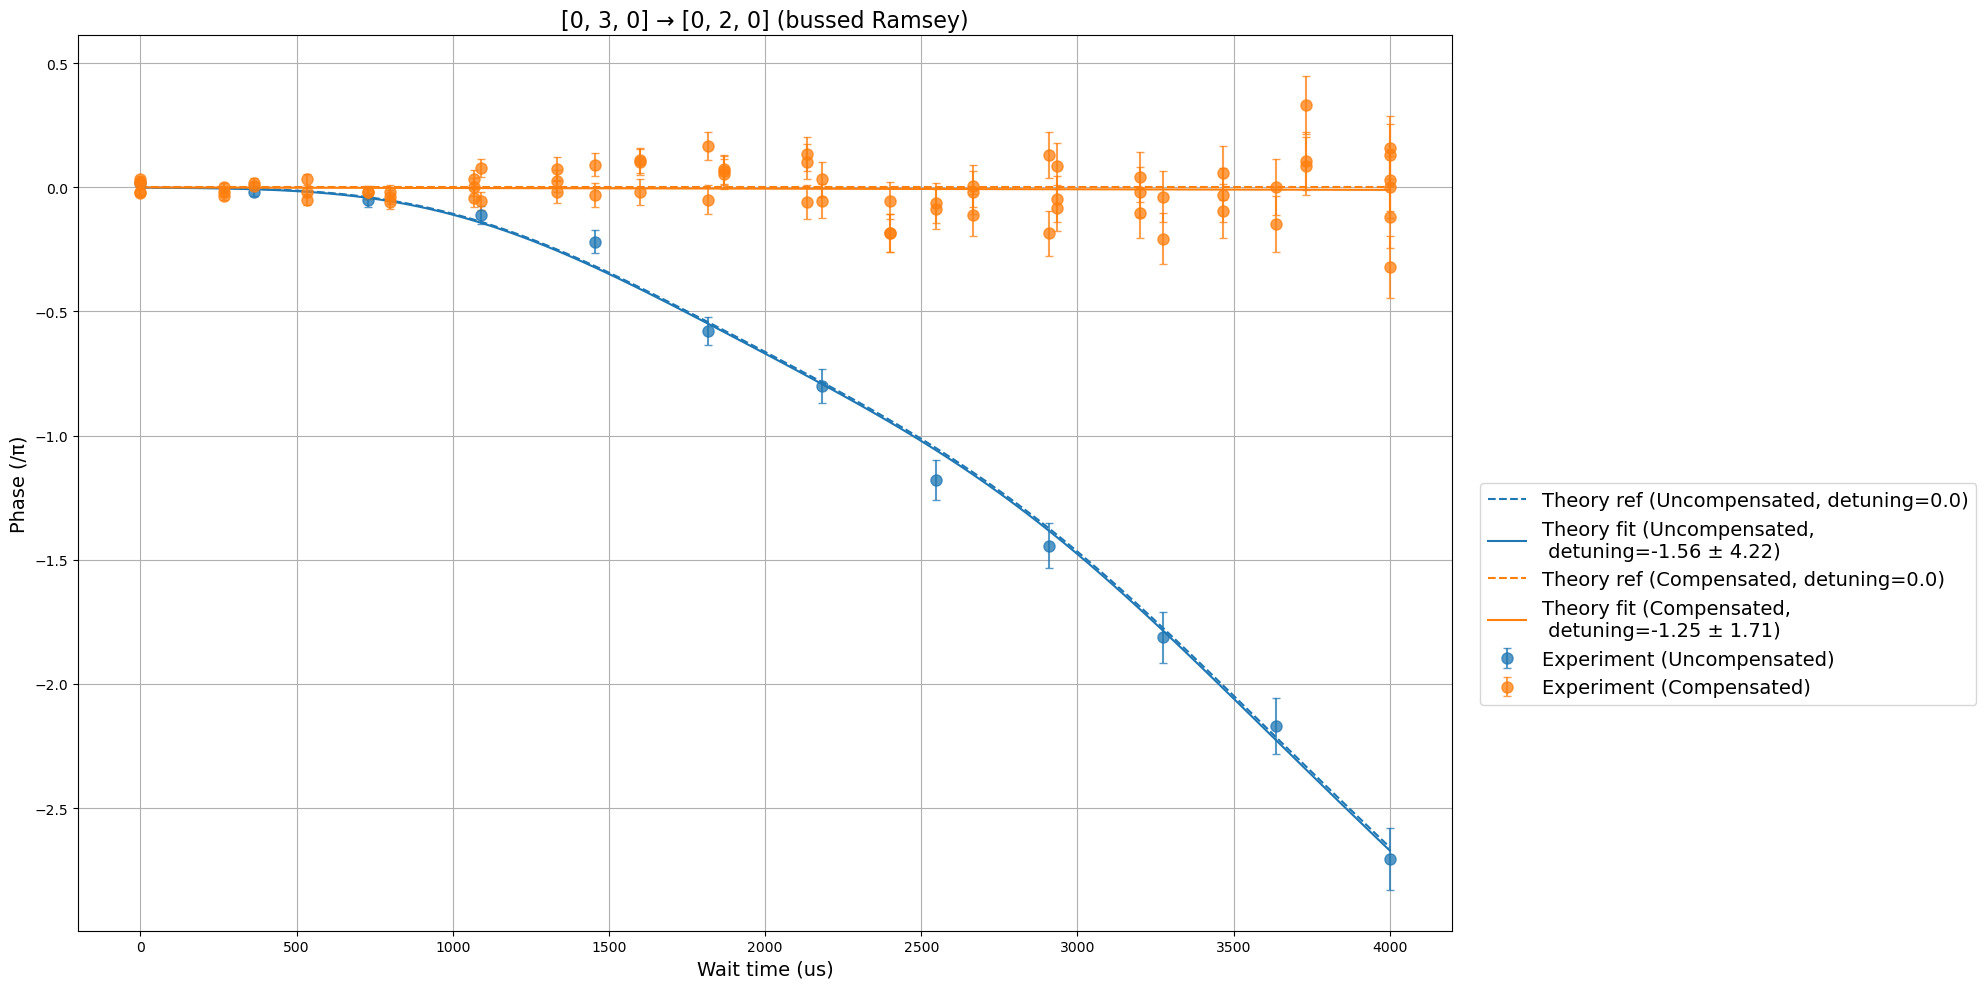

  saved -> Uncompensated_Phase_Data\((0,_3,_0),_(0,_2,_0)).txt
Transition: [[0, 3, 1], [0, 2, 0]]
{datetime.datetime(2026, 2, 20, 22, 58), datetime.datetime(2026, 2, 20, 23, 43), datetime.datetime(2026, 2, 20, 23, 15)}
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[97, 98, 98, 98, 97, 97, 100, 96, 100, 94, 96]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[98, 94, 95, 93, 96, 98, 94, 98, 95, 98, 94]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[99, 92, 96, 95, 94, 98, 96, 97, 96, 97, 99]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[97, 98, 98, 97, 97, 98, 92, 97, 97, 97, 98]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[93, 99, 96, 96, 95, 93, 97, 98, 93, 95, 97]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100

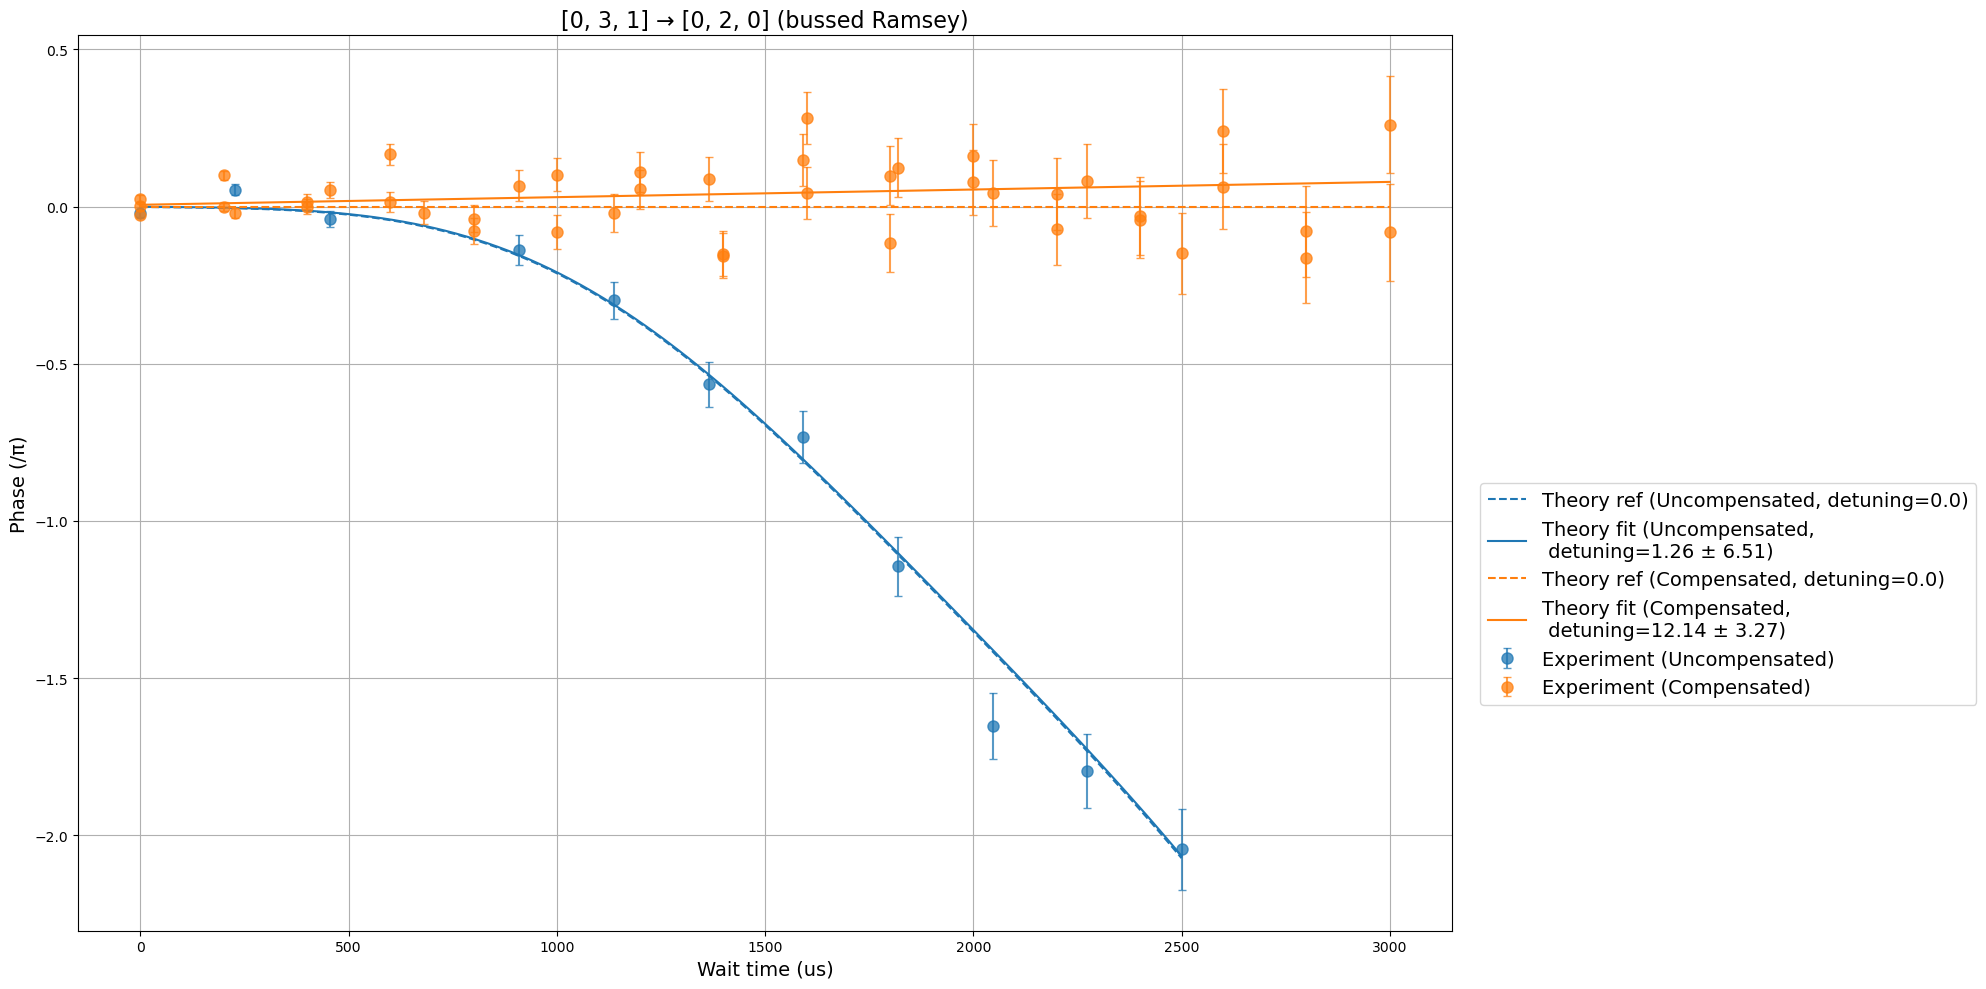

  saved -> Uncompensated_Phase_Data\((0,_3,_1),_(0,_2,_0)).txt
Transition: [[0, 3, 2], [0, 2, 0]]
{datetime.datetime(2026, 2, 21, 1, 21), datetime.datetime(2026, 2, 21, 7, 37)}
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[96, 93, 95, 95, 94, 94, 94, 92, 88, 97, 84]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[91, 95, 93, 90, 93, 95, 93, 90, 95, 93, 97]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[91, 95, 96, 95, 94, 90, 97, 93, 96, 96, 97]
Total sorted data points: 4400
Threshold recalculated using histogram: 13.5
(11, 100, 4)
13.5
[96, 96, 95, 95, 96, 93, 94, 95, 95, 89, 96]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[97, 96, 91, 96, 98, 93, 97, 98, 95, 98, 89]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[94, 96, 90, 98, 94, 95, 96, 96, 9

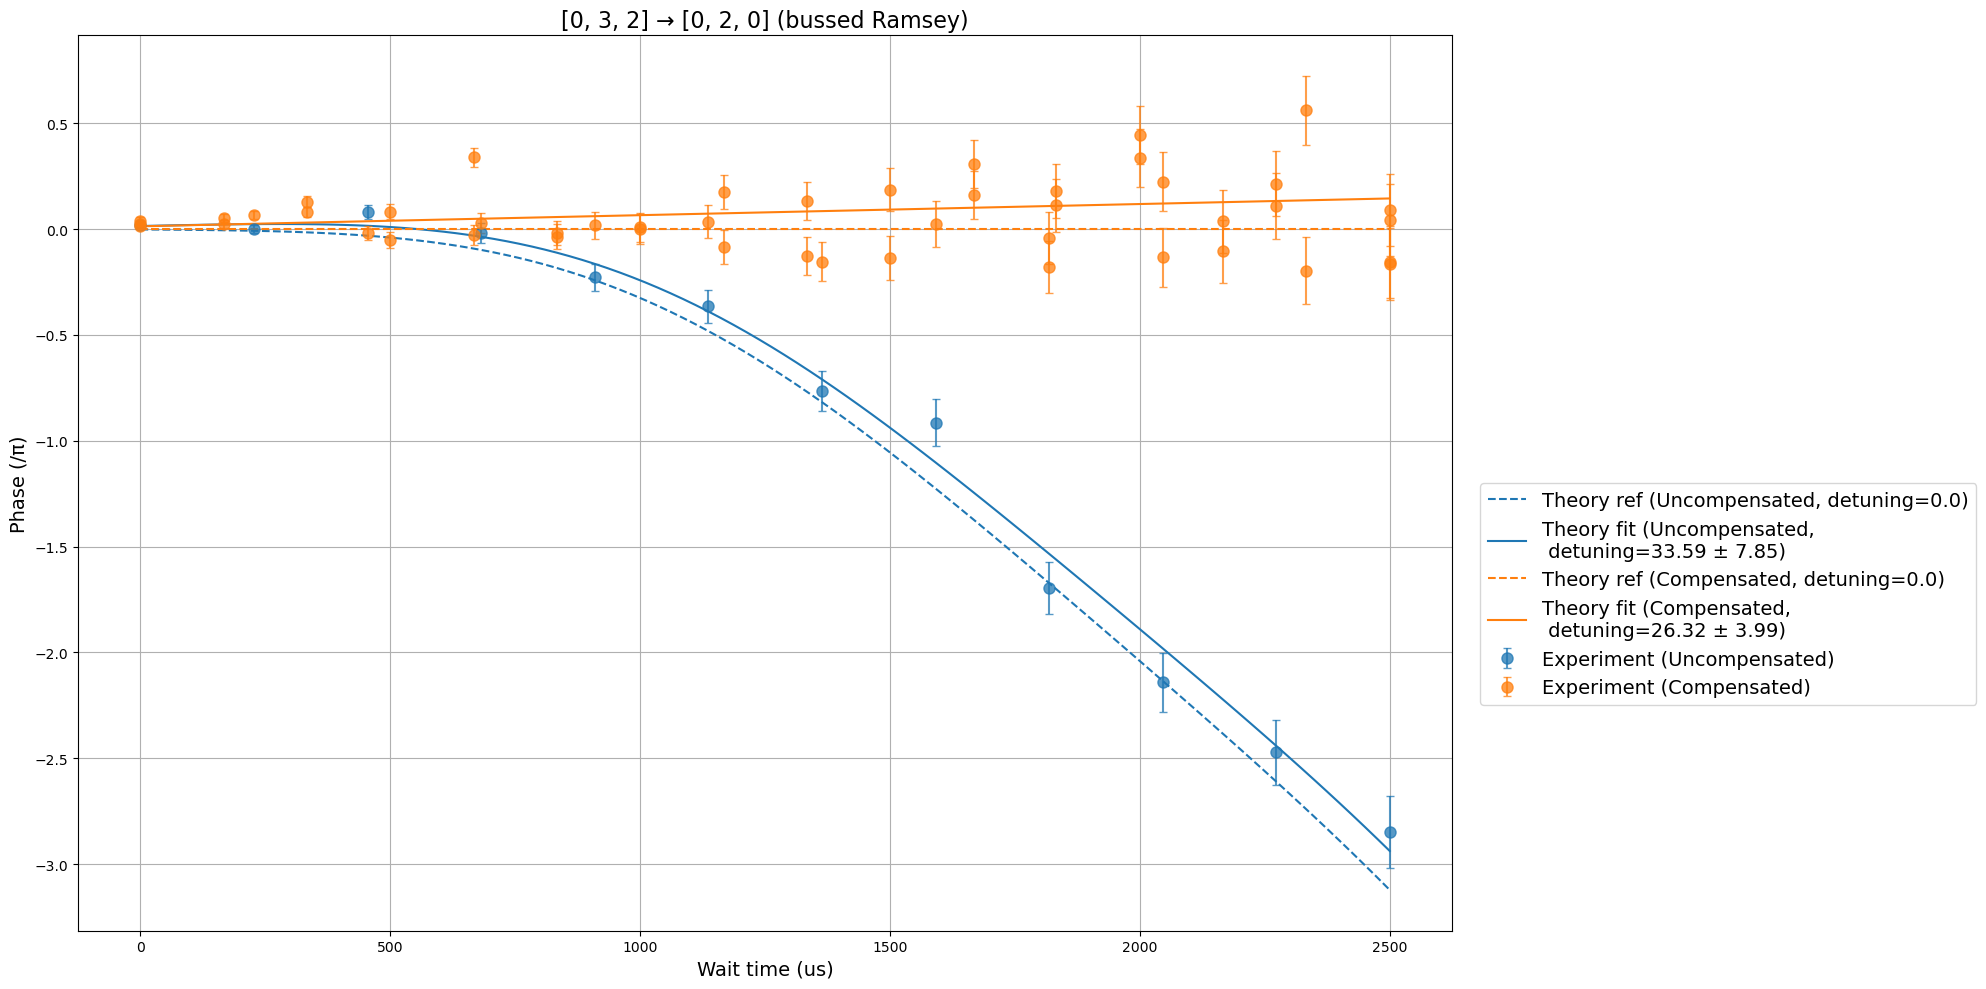

  saved -> Uncompensated_Phase_Data\((0,_3,_2),_(0,_2,_0)).txt
Transition: [[0, 4, -1], [0, 2, 0]]
{datetime.datetime(2026, 2, 21, 15, 26), datetime.datetime(2026, 2, 21, 14, 31), datetime.datetime(2026, 2, 21, 15, 47)}
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[86, 85, 84, 81, 88, 80, 83, 84, 84, 83, 87]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[81, 84, 87, 76, 79, 85, 85, 86, 84, 87, 83]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[85, 84, 82, 82, 81, 87, 82, 83, 82, 88, 85]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[91, 83, 85, 86, 86, 91, 90, 87, 84, 86, 92]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[86, 87, 88, 85, 81, 87, 90, 85, 89, 89, 82]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100,

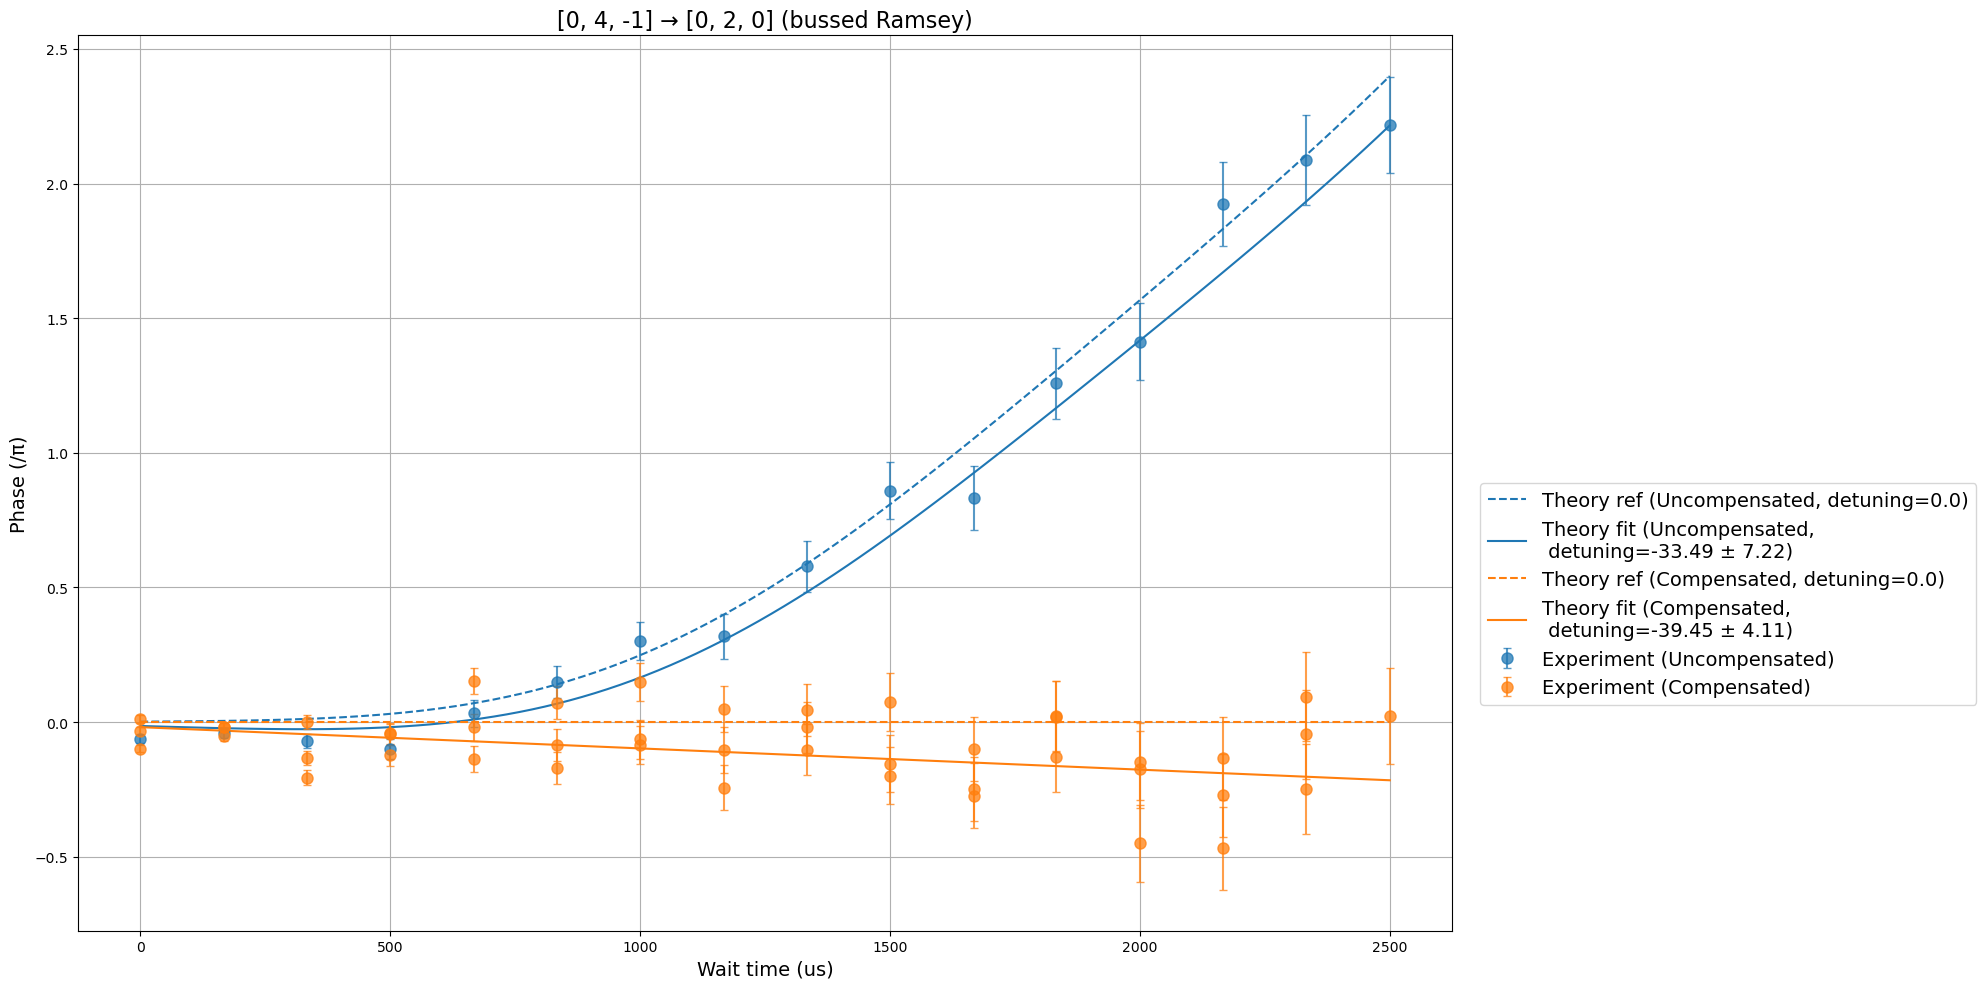

  saved -> Uncompensated_Phase_Data\((0,_4,_-1),_(0,_2,_0)).txt
Transition: [[0, 4, 0], [0, 2, 0]]
{datetime.datetime(2026, 2, 21, 11, 51)}
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[97, 95, 98, 96, 99, 96, 95, 96, 94, 96, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[92, 94, 94, 95, 93, 95, 93, 92, 91, 93, 94]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[91, 92, 89, 91, 93, 90, 98, 91, 88, 92, 90]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[96, 90, 90, 90, 91, 93, 87, 93, 84, 91, 94]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[91, 92, 94, 86, 92, 87, 85, 87, 94, 96, 89]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[81, 86, 92, 88, 85, 92, 92, 93, 87, 90, 89]
Total sorted data points: 

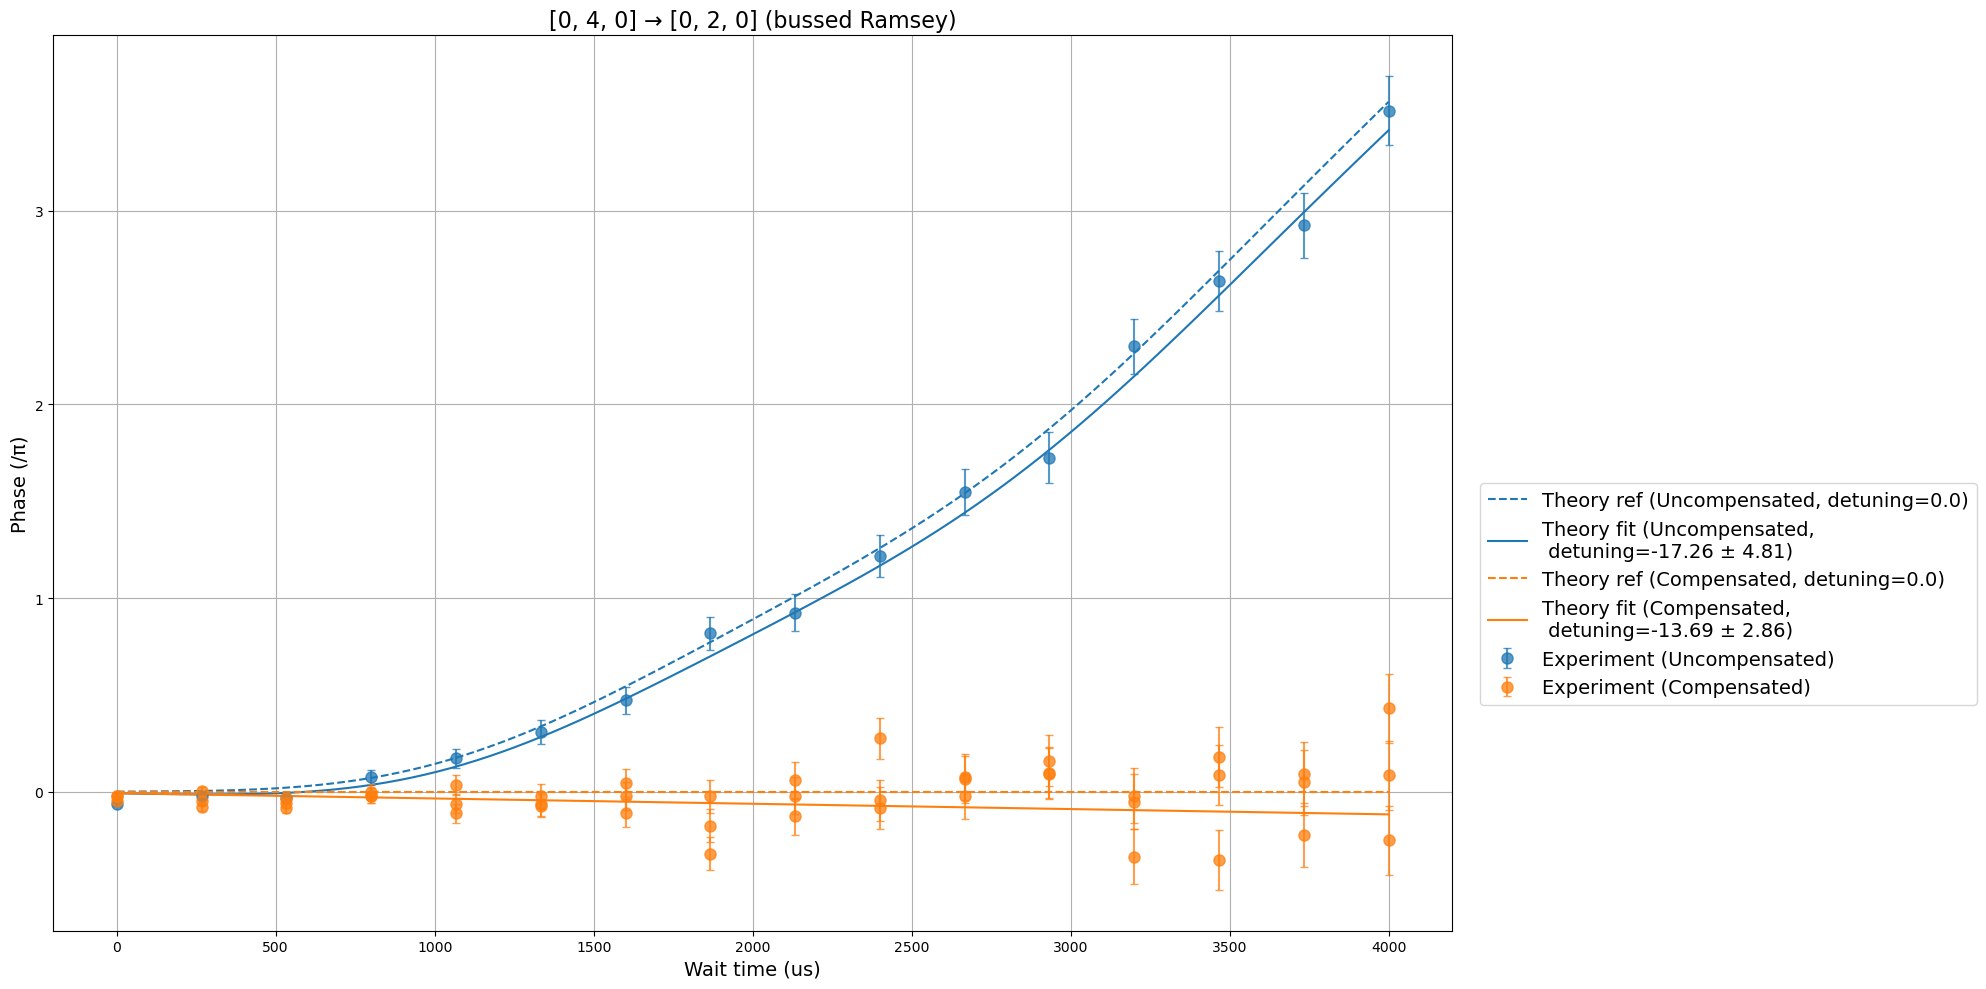

  saved -> Uncompensated_Phase_Data\((0,_4,_0),_(0,_2,_0)).txt
Transition: [[0, 4, 1], [0, 2, 0]]
{datetime.datetime(2026, 2, 21, 10, 0)}
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[96, 97, 98, 99, 98, 97, 97, 99, 99, 91, 97]
Total sorted data points: 4400
Threshold recalculated using histogram: 12.5
(11, 100, 4)
12.5
[96, 97, 98, 99, 98, 100, 96, 98, 97, 97, 98]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[99, 100, 95, 97, 96, 97, 98, 98, 98, 96, 99]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[98, 96, 98, 99, 100, 100, 98, 99, 100, 98, 98]
Total sorted data points: 4400
Threshold recalculated using histogram: 11.5
(11, 100, 4)
11.5
[97, 98, 100, 100, 100, 98, 100, 99, 99, 100, 99]
Total sorted data points: 4400
Threshold recalculated using histogram: 10.5
(11, 100, 4)
10.5
[100, 98, 100, 99, 99, 99, 99, 98, 98, 94, 98]
Total sorted dat

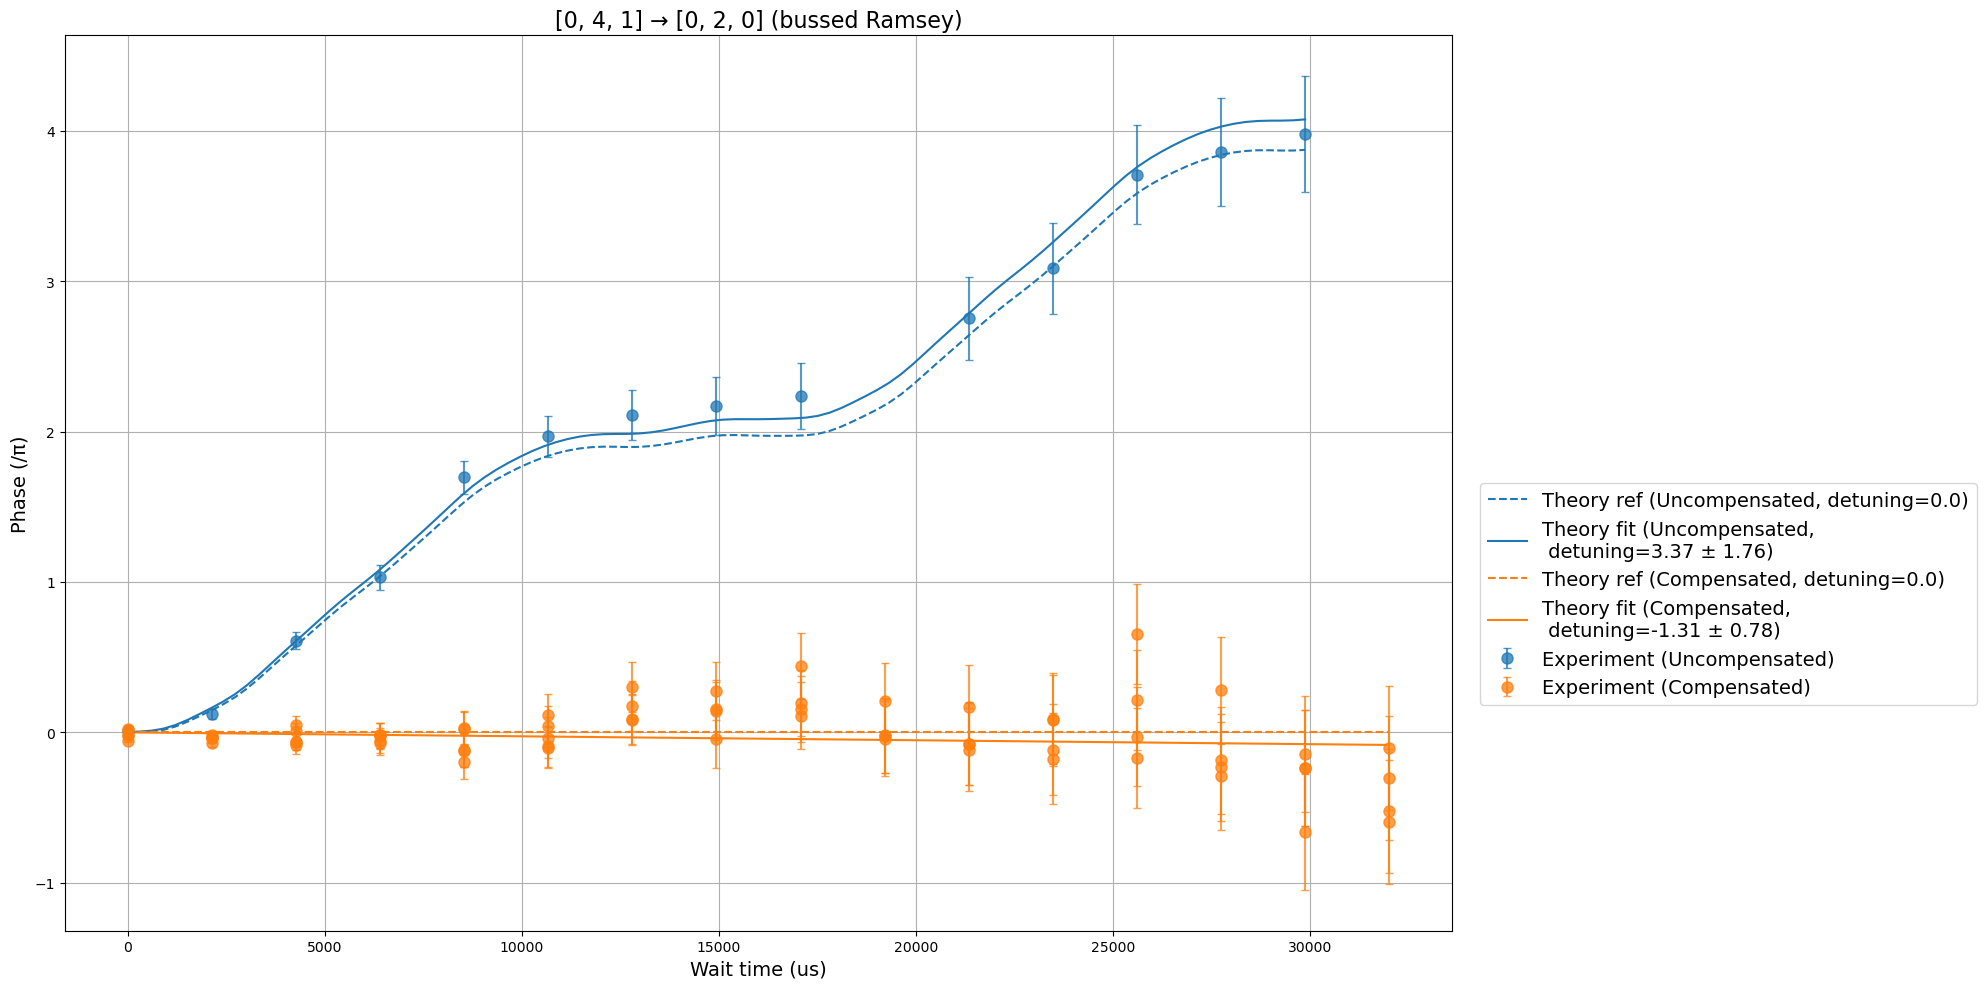

  saved -> Uncompensated_Phase_Data\((0,_4,_1),_(0,_2,_0)).txt


In [92]:
import json
import re
from pathlib import Path

def transition_to_filename(transition, suffix=""):
    """
    transition can be a string like '[[0, 3, -1], [0, 2, 0]]' or the evaluated list.
    """
    if not isinstance(transition, str):
        transition = str(transition)
    # keep digits, minus, commas, brackets -> convert other stuff to underscores
    safe = re.sub(r"[^\d\-\[\],]+", "_", transition).strip("_")
    safe = safe.replace("[", "(").replace("]", ")")  # optional: nicer-looking
    return f"{safe}{suffix}.txt"

def save_arrays_for_transition(out_dir, transition, exp_wait_times, exp_phases_pm1):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    filename = transition_to_filename(transition)
    out_path = out_dir / filename

    data = {
        "transition": transition if isinstance(transition, str) else str(transition),
        "exp_wait_times_us": list(map(float, exp_wait_times)),
        "exp_phases_pm1": list(map(float, exp_phases_pm1)),
    }

    # human-readable + still machine-loadable
    out_path.write_text(json.dumps(data, indent=2), encoding="utf-8")
    return out_path

# ---- your loop ----
out_dir_uncomp = "Uncompensated_Phase_Data"
out_dir_comp = "Compensated_Phase_Data"

for item in unique_list:
    transition_str = item["transition"]
    print(f'Transition: {transition_str}')

    payloads = run_full_bussed_ramsey_pipeline_readonly(
        target_transitions=eval(transition_str),
        log_path=log_path,
        directory_path=directory_path,
        Z_drive_raw_data=Z_drive_raw_data,
        LT_comp_mode="both",
        do_plot=True
    )

    exp_wait_times = payloads[True]["exp_wait_us"]
    exp_phases = payloads[True]["exp_phase_mod_over_pi"]
    exp_phases_pm1 = ((exp_phases + 1.0) % 2.0) - 1.0
    exp_phase_unw = _unwrap_over_pi(exp_phases_pm1)
    out_path = save_arrays_for_transition(
        out_dir=out_dir_comp,
        transition=transition_str,
        exp_wait_times=exp_wait_times,
        exp_phases_pm1=exp_phase_unw
    )

    exp_wait_times = payloads[False]["exp_wait_us"]
    exp_phases = payloads[False]["exp_phase_mod_over_pi"]
    exp_phases_pm1 = ((exp_phases + 1.0) % 2.0) - 1.0
    exp_phase_unw = _unwrap_over_pi(exp_phases_pm1)
    out_path = save_arrays_for_transition(
        out_dir=out_dir_uncomp,
        transition=transition_str,
        exp_wait_times=exp_wait_times,
        exp_phases_pm1=exp_phase_unw
    )

    print("  saved ->", out_path)